# DCDM-guided forecast for the unfinished low-$\epsilon$ accDM grid

Ten notebook buduje **diagnostyczną prognozę**, a nie nową powierzchnię wiarygodności
do wyznaczania końcowych ograniczeń. Łączy trzy informacje:

1. wszystkie obecnie ukończone fity accDM;
2. lokalną interpolację accDM, prowadzoną osobno po obu stronach granicy
   $f_{\rm acc}=0.1$;
3. jedynie **kształt** powierzchni DCDM w kierunku $\epsilon$, po zakotwiczeniu i
   odpornej kalibracji do istniejących punktów accDM.

Ukończone punkty accDM nigdy nie są zastępowane prognozą. Wyjątkiem są dwa znane,
punktowe artefakty fitu przy $(14.7143,-1.375)$ i $(15.0,-1.375)$: ich surowe
$\chi^2$ pozostają w tabeli audytowej, ale powierzchnia prezentacyjna wykorzystuje
lokalną interpolację sąsiadów.

Przy pierwszym uruchomieniu notebook zapisuje `loweps_prediction_snapshot.csv`.
Kolejne uruchomienia **nie przeliczają** tej prognozy z użyciem nowych fitów; nowe
wyniki trafiają wyłącznie do porównania „prediction vs reality”. Aby świadomie
zbudować nowy snapshot, ustaw `ACCDM_FORCE_REBUILD_PREDICTION=1`.

> Kontury przebiegające przez obszar prognozowany są przewidywaniem wyglądu mapy,
> nie wynikiem statystycznym i nie powinny być cytowane jako ograniczenie.

Notebook zachowuje konserwatywny snapshot do późniejszej walidacji, ale dodatkowo
tworzy osobny produkt `DCDM-conditioned expectation`. W nim ukończone punkty nowego
zakresu są jedynie markerami kontrolnymi: pole koloru pokazuje hipotezę, która na
granicy starej siatki zgadza się z accDM, a głębiej przechodzi do pełnej morfologii
DCDM. To właśnie ten produkt służy do wizualnego przewidywania nowej domeny.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator, griddata
from scipy.optimize import least_squares
from scipy.stats import spearmanr


def env_bool(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return value.strip().lower() not in {"0", "false", "no", "off", ""}


def find_project_root(start=Path.cwd()):
    override = os.environ.get("ACCDM_PROJECT_ROOT")
    if override:
        return Path(override).expanduser().resolve()
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "lyalpha_pt").is_dir():
            return candidate
    return start


def env_path(name, default):
    raw = os.environ.get(name)
    return Path(raw).expanduser().resolve() if raw else Path(default).resolve()


PROJECT_ROOT = find_project_root()
TRANSITION_LOGF = -1.0
ORIGINAL_MAX_LOGM = 18.0
STABLE_LOGEPS_WINDOW = (-2.5, -2.0)
T_REFERENCE_GYR = 14.0
DELTA_CHI2_68_2D = 2.30
DELTA_CHI2_95_2D = 5.991
DISPLAY_DELTA_MAX = 20.0

# Forecast controls. DCDM contributes only to unfinished high-f extension cells.
CALIBRATION_LOGM_RANGE = (15.0, 18.0)
CALIBRATION_BETA_BOUNDS = (0.0, 3.0)
CV_CUTOFFS = (16.5, 17.0, 17.5)
CV_LOOKAHEAD = 0.75
CANDIDATE_DCDM_WEIGHTS = (0.0, 0.25, 0.50, 0.75)
DEFAULT_DCDM_WEIGHT = 0.50
DCDM_WEIGHT_RAMP_STEPS = 3.0
LOCAL_EDGE_POINTS = 4
LOCAL_EDGE_DAMPING_SCALE = 0.75
LOCAL_EDGE_MAX_ABS_SLOPE = 20.0

# Illustrative DCDM-morphology product.  This is deliberately separate from
# the conservative frozen forecast used by the later validation section.
# Over this effective-epsilon width the field moves continuously from the
# measured accDM edge to the full DCDM morphology.
DCDM_MORPH_TRANSITION_DEX = 0.45

# Ukończony fit pozostaje pokazany jako pomiar, lecz do kalibracji i kotwic
# prognozy dopuszczamy tylko rozwiązania, które przeszły podstawowy audyt.
TRUST_REQUIRE_OPTIMIZER_SUCCESS = True
MIN_TRUSTED_BOUND_DISTANCE = 0.02

# Two completed but manifestly isolated low-f fit artifacts visible as blue holes.
KNOWN_LOWF_REPAIR_COORDS = (
    (14.7142857142857, -1.375),
    (15.0000000000000, -1.375),
)

SAVE_OUTPUTS = env_bool("ACCDM_SAVE_OUTPUTS", True)
FORCE_REBUILD_PREDICTION = env_bool("ACCDM_FORCE_REBUILD_PREDICTION", False)
ALLOW_LOCAL_ONLY = env_bool("ACCDM_ALLOW_LOCAL_ONLY", False)

DEFAULT_ANALYSIS_DIR = (
    PROJECT_ROOT / "runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1"
)
BASE_ANALYSIS_DIR = env_path("ACCDM_BASE_ANALYSIS_DIR", DEFAULT_ANALYSIS_DIR)
OUTPUT_DIR = env_path(
    "ACCDM_PREDICTION_OUTPUT_DIR",
    PROJECT_ROOT / "runs/accdm/analysis_dcdm_guided_loweps_forecast_v1",
)

EXTENSION_CAMPAIGNS = [
    {
        "label": "loweps_low_q1001",
        "directory": env_path(
            "ACCDM_LOWEPS_LOWF_CAMPAIGN",
            PROJECT_ROOT / "runs/accdm/accdm_scan_loweps_lowf_q1001_v1",
        ),
        "momentum_bins": 1001,
        "priority": 100,
        "region": "low",
    },
    {
        "label": "loweps_high_q5001",
        "directory": env_path(
            "ACCDM_LOWEPS_HIGHF_CAMPAIGN",
            PROJECT_ROOT / "runs/accdm/accdm_scan_loweps_highf_q5001_v1",
        ),
        "momentum_bins": 5001,
        "priority": 100,
        "region": "high",
    },
]

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root       :", PROJECT_ROOT)
print("Base accDM analysis:", BASE_ANALYSIS_DIR)
print("Forecast output    :", OUTPUT_DIR)
print("Freeze existing snapshot:", not FORCE_REBUILD_PREDICTION)


Project root       : /home/2/ks405818/Master/lyalpha_one_loop
Base accDM analysis: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1
Forecast output    : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1
Freeze existing snapshot: True


## 1. Wczytanie accDM i bieżącego stanu kampanii

Punkt wchodzi do zbioru zmierzonego tylko wtedy, gdy istnieją jednocześnie poprawny
`fits/<point>.json` i marker `status/fit/<point>.done.json`. Zatem aktywny, oczekujący
lub nieudany job nie zostanie przypadkiem uznany za wynik.


In [2]:
def active_mask(frame):
    if "active" not in frame:
        return np.ones(len(frame), dtype=bool)
    return frame["active"].astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def coordinate_key(logm, logf):
    return f"{float(logm):.10f}|{float(logf):.10f}"


def fit_summary(path):
    payload = json.loads(path.read_text(encoding="utf-8"))
    loop = payload.get("fits", {}).get("one_loop")
    if loop is None or not np.isfinite(float(loop.get("chi2", np.nan))):
        return None
    diagnostics = loop.get("boundary_diagnostics", [])
    nearest = None
    if diagnostics:
        nearest = min(
            diagnostics,
            key=lambda item: float(item["relative_distance_to_nearest_bound"]),
        )
    return {
        "chi2_one_loop": float(loop["chi2"]),
        "chi2_per_dof": float(loop.get("chi2_per_dof", np.nan)),
        "optimizer_success": bool(loop.get("optimizer_success", False)),
        "minimum_bound_distance": (
            float(nearest["relative_distance_to_nearest_bound"])
            if nearest is not None else np.nan
        ),
        "minimum_bound_parameter": nearest["parameter"] if nearest is not None else None,
    }


def load_extension_campaign(source):
    directory = Path(source["directory"])
    manifest_path = directory / "manifest.csv"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing extension manifest: {manifest_path}")
    manifest = pd.read_csv(manifest_path)
    manifest = manifest.loc[active_mask(manifest)].copy()
    rows = []
    for record in manifest.to_dict(orient="records"):
        point_id = str(record["point_id"])
        fit_path = directory / "fits" / f"{point_id}.json"
        fit_done = directory / "status/fit" / f"{point_id}.done.json"
        fit_failed = directory / "status/fit" / f"{point_id}.failed.json"
        theory_path = directory / "theory" / f"{point_id}.npz"
        theory_done = directory / "status/theory" / f"{point_id}.done.json"
        theory_failed = directory / "status/theory" / f"{point_id}.failed.json"
        fit_has_failure_marker = fit_failed.is_file()
        theory_has_failure_marker = theory_failed.is_file()
        row = {
            **record,
            "coordinate_key": coordinate_key(record["log10m_acc"], record["log10f_acc"]),
            "expected_region": source["region"],
            "source_label": source["label"],
            "source_directory": str(directory),
            "source_priority": int(source["priority"]),
            "momentum_bins": int(source["momentum_bins"]),
            "theory_complete": (
                theory_path.is_file() and theory_done.is_file()
                and not theory_has_failure_marker
            ),
            "theory_failed": theory_has_failure_marker,
            "fit_complete": (
                fit_path.is_file() and fit_done.is_file()
                and not fit_has_failure_marker
            ),
            "fit_failed": fit_has_failure_marker,
            "chi2_one_loop": np.nan,
        }
        if row["fit_complete"]:
            parsed = fit_summary(fit_path)
            if parsed is not None:
                row.update(parsed)
        row["missing_reason"] = (
            "fit failed" if row["fit_failed"] else
            "theory failed" if row["theory_failed"] else
            "fit pending or missing" if row["theory_complete"] else
            "theory active, pending, or absent"
        )
        rows.append(row)
    return pd.DataFrame(rows)


base_sampled_path = BASE_ANALYSIS_DIR / "updated_hybrid_sampled_profile_likelihood.csv"
base_missing_path = BASE_ANALYSIS_DIR / "updated_hybrid_cross_markers.csv"
summary_path = BASE_ANALYSIS_DIR / "updated_hybrid_analysis_summary.json"
if not base_sampled_path.is_file():
    raise FileNotFoundError(base_sampled_path)

base_sampled = pd.read_csv(base_sampled_path)
base_missing = (
    pd.read_csv(base_missing_path)
    if base_missing_path.is_file()
    else pd.DataFrame(columns=["log10m_acc", "log10f_acc"])
)
required = {"log10m_acc", "log10f_acc", "chi2_one_loop"}
missing_columns = required - set(base_sampled.columns)
if missing_columns:
    raise KeyError(f"Base accDM table lacks columns: {sorted(missing_columns)}")

analysis_summary = (
    json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.is_file() else {}
)
LCDM_ONE_LOOP_CHI2 = float(analysis_summary.get("lcdm_reference_chi2", 193.105787))

base_sampled = base_sampled.loc[np.isfinite(base_sampled["chi2_one_loop"])].copy()
base_sampled["coordinate_key"] = [
    coordinate_key(m, f) for m, f in zip(base_sampled["log10m_acc"], base_sampled["log10f_acc"])
]
base_sampled["expected_region"] = np.where(
    base_sampled["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
)
base_sampled["source_priority"] = 0
if "source_label" not in base_sampled:
    base_sampled["source_label"] = "validated_hybrid_base"
if "momentum_bins" not in base_sampled:
    base_sampled["momentum_bins"] = np.where(
        base_sampled["log10f_acc"] <= TRANSITION_LOGF, 1001, 5001
    )

if not base_missing.empty:
    base_missing["coordinate_key"] = [
        coordinate_key(m, f) for m, f in zip(base_missing["log10m_acc"], base_missing["log10f_acc"])
    ]
    base_missing["expected_region"] = np.where(
        base_missing["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
    )

extension_frames = [load_extension_campaign(source) for source in EXTENSION_CAMPAIGNS]
extension_inventory = pd.concat(extension_frames, ignore_index=True, sort=False)
extension_completed = extension_inventory.loc[np.isfinite(extension_inventory["chi2_one_loop"])].copy()

sampled = pd.concat([base_sampled, extension_completed], ignore_index=True, sort=False)
sampled = (
    sampled.sort_values(["coordinate_key", "source_priority", "source_label"])
    .drop_duplicates("coordinate_key", keep="last")
    .copy()
)

if "optimizer_success" in sampled:
    optimizer_success = sampled["optimizer_success"]
    if optimizer_success.dtype != bool:
        optimizer_success = optimizer_success.astype(str).str.strip().str.lower().isin(
            {"true", "1", "yes"}
        )
    else:
        optimizer_success = optimizer_success.fillna(False)
else:
    optimizer_success = pd.Series(True, index=sampled.index)

bound_distance = pd.to_numeric(
    sampled.get("minimum_bound_distance", pd.Series(np.nan, index=sampled.index)),
    errors="coerce",
)
trusted_for_forecast = pd.Series(True, index=sampled.index)
if TRUST_REQUIRE_OPTIMIZER_SUCCESS:
    trusted_for_forecast &= optimizer_success
# Brak diagnostyki granic nie jest automatycznie porażką. Jeżeli diagnostyka jest
# dostępna, odrzucamy tylko rozwiązania rzeczywiście przyklejone do ściany boxa.
trusted_for_forecast &= bound_distance.isna() | (
    bound_distance >= MIN_TRUSTED_BOUND_DISTANCE
)
configured_repair_keys = {
    coordinate_key(logm, logf) for logm, logf in KNOWN_LOWF_REPAIR_COORDS
}
trusted_for_forecast &= ~sampled["coordinate_key"].isin(configured_repair_keys)
sampled["trusted_for_forecast"] = trusted_for_forecast.astype(bool)

base_expected = pd.concat([
    base_sampled[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]],
    base_missing[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]],
], ignore_index=True)
extension_expected = extension_inventory[
    ["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]
]
expected_points = (
    pd.concat([base_expected, extension_expected], ignore_index=True)
    .drop_duplicates("coordinate_key", keep="last")
    .sort_values(["log10f_acc", "log10m_acc"])
    .reset_index(drop=True)
)
missing_now = expected_points.loc[
    ~expected_points["coordinate_key"].isin(sampled["coordinate_key"])
].copy()

extension_status = extension_inventory.groupby("source_label").agg(
    planned=("point_id", "size"),
    theory_complete=("theory_complete", "sum"),
    theory_failed=("theory_failed", "sum"),
    fit_complete=("fit_complete", "sum"),
    fit_failed=("fit_failed", "sum"),
    fitted=("chi2_one_loop", "count"),
)
extension_status["coverage"] = extension_status["fitted"] / extension_status["planned"]

print("Validated base points   :", len(base_sampled))
print("Completed extension fits:", len(extension_completed))
print("Expected full grid cells:", len(expected_points))
print("Missing now             :", len(missing_now))
print("Trusted forecast anchors:", int(sampled["trusted_for_forecast"].sum()),
      "/", len(sampled))
display(extension_status)


Validated base points   : 1425
Completed extension fits: 175
Expected full grid cells: 1740
Missing now             : 140
Trusted forecast anchors: 1578 / 1600


,planned,theory_complete,theory_failed,fit_complete,fit_failed,fitted,coverage
source_label,,,,,,,
loweps_high_q5001,120,8,1,8,0,8,0.066667
loweps_low_q1001,170,167,3,167,0,167,0.982353


## 2. Współrzędne efektywne i stabilny punkt odniesienia

Normalizacja pozostaje zamrożona na najlepszym **zmierzonym** punkcie low-f w oknie
$-2.5\leq\log_{10}\epsilon_{\rm eff}\leq-2.0$. Prognoza nie może utworzyć nowego
globalnego minimum; wartości ujemne są obcinane do zera wyłącznie przy rysowaniu.


In [3]:
def eta_from_log10_mass(log10m_acc):
    return 10.0 ** (11.0 - np.asarray(log10m_acc, dtype=float))


def epsilon_effective_from_log10_mass(log10m_acc):
    eta = eta_from_log10_mass(log10m_acc)
    recoil = np.sqrt(eta * (eta + 2.0))
    return recoil / (np.sqrt(1.0 + recoil**2) + recoil)


def gamma_effective_from_log10_fraction(log10f_acc, t_reference_gyr=T_REFERENCE_GYR):
    fraction = 10.0 ** np.asarray(log10f_acc, dtype=float)
    gamma = np.full_like(fraction, np.inf, dtype=float)
    finite = fraction < 1.0
    gamma[finite] = -np.log1p(-fraction[finite]) / float(t_reference_gyr)
    return gamma


sampled["log10_epsilon_eff"] = np.log10(
    epsilon_effective_from_log10_mass(sampled["log10m_acc"])
)
sampled["log10_gamma_eff"] = np.log10(
    gamma_effective_from_log10_fraction(sampled["log10f_acc"])
)

repair_keys = {coordinate_key(m, f) for m, f in KNOWN_LOWF_REPAIR_COORDS}
stable_candidates = sampled.loc[
    sampled["log10_epsilon_eff"].between(*STABLE_LOGEPS_WINDOW)
    & (sampled["log10f_acc"] <= TRANSITION_LOGF + 1e-12)
    & ~sampled["coordinate_key"].isin(repair_keys)
].copy()
if stable_candidates.empty:
    raise RuntimeError("No measured low-f point lies in the stable epsilon window.")

stable_reference = stable_candidates.loc[stable_candidates["chi2_one_loop"].idxmin()]
REFERENCE_CHI2 = float(stable_reference["chi2_one_loop"])

print("Stable measured reference")
print(" point  :", stable_reference.get("point_id", stable_reference["coordinate_key"]))
print(f" logm   : {stable_reference['log10m_acc']:.6f}")
print(f" logf   : {stable_reference['log10f_acc']:.6f}")
print(f" logeps : {stable_reference['log10_epsilon_eff']:.6f}")
print(f" chi2   : {REFERENCE_CHI2:.9f}")
print(f" vs LCDM: {REFERENCE_CHI2 - LCDM_ONE_LOOP_CHI2:+.9f}")


Stable measured reference
 point  : accdm_logm15p7142857142857_logfm1p3
 logm   : 15.714286
 logf   : -1.300000
 logeps : -2.209324
 chi2   : 188.986412635
 vs LCDM: -4.210197964


## 3. Powierzchnia DCDM

Obsługiwane są oba spotykane formaty: nowy `campaign_profile_likelihood.csv` oraz
starszy `dcdm_fit_master_table.csv`. DCDM nie jest nigdy ekstrapolowane poza zakres
jego rzeczywistych punktów: interpolator liniowy zwraca brak wartości poza ich
otoczką wypukłą, a waga DCDM spada tam do zera. Jeśli automatyczne wyszukanie nie
znajdzie pliku, ustaw np.

```bash
export ACCDM_DCDM_PROFILE_CSV=/pełna/ścieżka/do/campaign_profile_likelihood.csv
```

Opcjonalny `ACCDM_ALLOW_LOCAL_ONLY=1` uruchamia notebook bez DCDM, lecz wtedy cała
prognoza jest oznaczona jako lokalna.


In [4]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_sorted_strings(values):
    payload = "\n".join(sorted(str(value) for value in values)).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def locate_dcdm_profile():
    override = os.environ.get("ACCDM_DCDM_PROFILE_CSV")
    candidates = []
    if override:
        candidates.append(Path(override).expanduser())
    candidates.extend([
        PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv",
        PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/dcdm_fit_master_table.csv",
        PROJECT_ROOT / "plots_dcdm/dcdm_fit_master_table.csv",
        PROJECT_ROOT.parent / "jobs_cluster/Lya_forest/plots_dcdm/dcdm_fit_master_table.csv",
        Path("/home/2/ks405818/Master/jobs_cluster/Lya_forest/plots_dcdm/dcdm_fit_master_table.csv"),
    ])
    for path in candidates:
        if path.is_file():
            return path.resolve()
    for pattern in (
        "runs/dcdm/**/campaign_profile_likelihood.csv",
        "runs/dcdm/**/dcdm_fit_master_table.csv",
    ):
        matches = sorted(PROJECT_ROOT.glob(pattern))
        if matches:
            return matches[-1].resolve()
    return None


def choose_column(frame, candidates, description):
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(f"Cannot identify {description}; tried {candidates}.")


DCDM_PROFILE_CSV = locate_dcdm_profile()
DCDM_AVAILABLE = DCDM_PROFILE_CSV is not None

if not DCDM_AVAILABLE and not ALLOW_LOCAL_ONLY:
    raise FileNotFoundError(
        "DCDM profile table was not found. Set ACCDM_DCDM_PROFILE_CSV to "
        "campaign_profile_likelihood.csv (or dcdm_fit_master_table.csv)."
    )

if DCDM_AVAILABLE:
    dcdm_raw = pd.read_csv(DCDM_PROFILE_CSV)
    gamma_column = choose_column(
        dcdm_raw,
        ["log10_gamma_gyr_inverse", "log10_Gamma_Gyr_inv", "log10_gamma_gyr_inv"],
        "DCDM log10 Gamma column",
    )
    epsilon_column = choose_column(dcdm_raw, ["log10_epsilon"], "DCDM log10 epsilon column")
    chi2_column = choose_column(dcdm_raw, ["chi2_one_loop", "chi2_min"], "DCDM chi2 column")
    if "has_fit" in dcdm_raw:
        keep = dcdm_raw["has_fit"].astype(str).str.lower().isin({"true", "1", "yes"})
        dcdm_raw = dcdm_raw.loc[keep].copy()
    dcdm = dcdm_raw.rename(columns={
        gamma_column: "log10_gamma",
        epsilon_column: "log10_epsilon",
        chi2_column: "chi2",
    })
    dcdm = dcdm.loc[
        np.isfinite(dcdm["log10_gamma"])
        & np.isfinite(dcdm["log10_epsilon"])
        & np.isfinite(dcdm["chi2"])
    ].copy()
    dcdm["delta_chi2"] = dcdm["chi2"] - float(dcdm["chi2"].min())
    dcdm_gamma_axis = np.sort(dcdm["log10_gamma"].unique())
    dcdm_epsilon_axis = np.sort(dcdm["log10_epsilon"].unique())
    if len(dcdm_gamma_axis) < 2 or len(dcdm_epsilon_axis) < 2:
        raise RuntimeError("DCDM profile must span at least two Gamma and epsilon values.")
    dcdm_grid = dcdm.pivot_table(
        index="log10_epsilon", columns="log10_gamma", values="delta_chi2", aggfunc="median"
    ).reindex(index=dcdm_epsilon_axis, columns=dcdm_gamma_axis).to_numpy(dtype=float)
    dcdm_unique = dcdm.groupby(
        ["log10_epsilon", "log10_gamma"], as_index=False
    )["delta_chi2"].median()
    # Scattered linear interpolation returns NaN outside the convex hull. We do not
    # patch unsupported DCDM regions with nearest-neighbour values.
    dcdm_interpolator = LinearNDInterpolator(
        np.column_stack([
            dcdm_unique["log10_epsilon"], dcdm_unique["log10_gamma"]
        ]),
        dcdm_unique["delta_chi2"].to_numpy(dtype=float),
        fill_value=np.nan,
    )
    DCDM_FILE_HASH = sha256_file(DCDM_PROFILE_CSV)
    print("DCDM profile:", DCDM_PROFILE_CSV)
    print("DCDM domain : gamma", (dcdm_gamma_axis.min(), dcdm_gamma_axis.max()),
          "epsilon", (dcdm_epsilon_axis.min(), dcdm_epsilon_axis.max()))
else:
    dcdm_raw = dcdm = pd.DataFrame()
    dcdm_gamma_axis = dcdm_epsilon_axis = np.array([], dtype=float)
    dcdm_grid = None
    dcdm_interpolator = None
    DCDM_FILE_HASH = "local-only"
    warnings.warn("DCDM unavailable: using local-only forecast by explicit request.")


def evaluate_dcdm(logm, logf):
    logm = np.asarray(logm, dtype=float)
    logf = np.asarray(logf, dtype=float)
    shape = np.broadcast_shapes(logm.shape, logf.shape)
    logm = np.broadcast_to(logm, shape)
    logf = np.broadcast_to(logf, shape)
    result = np.full(shape, np.nan, dtype=float)
    if not DCDM_AVAILABLE:
        return result
    logepsilon = np.log10(epsilon_effective_from_log10_mass(logm))
    gamma = gamma_effective_from_log10_fraction(logf)
    loggamma = np.full(shape, np.nan, dtype=float)
    finite = np.isfinite(gamma) & (gamma > 0)
    loggamma[finite] = np.log10(gamma[finite])
    inside = (
        finite
        & (loggamma >= dcdm_gamma_axis.min())
        & (loggamma <= dcdm_gamma_axis.max())
        & (logepsilon >= dcdm_epsilon_axis.min())
        & (logepsilon <= dcdm_epsilon_axis.max())
    )
    if np.any(inside):
        result[inside] = dcdm_interpolator(
            np.column_stack([logepsilon[inside], loggamma[inside]])
        )
    return result


DCDM profile: /home/2/ks405818/Master/lyalpha_one_loop/runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv
DCDM domain : gamma (-3.0, -0.0) epsilon (-4.0, -0.3010299956639812)


## 4. Lokalna powierzchnia accDM i naprawa dwóch niebieskich dziur

Najpierw zachowujemy pełną macierz surową. Dwa znane odstające fity są następnie
ustawiane na `NaN` tylko w kopii roboczej. Każdy z nich jest odtwarzany z interpolacji
lewo–prawo i dół–góra, a wynik jest ograniczony do zakresu bezpośrednich sąsiadów.
Pozostałe braki wypełniane są iteracyjnie średnią najbliższych osiowych sąsiadów,
oddzielnie dla q=1001 i q=5001.


In [5]:
x_grid = np.sort(expected_points["log10m_acc"].unique())
y_grid = np.sort(expected_points["log10f_acc"].unique())
chi_raw_grid = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="chi2_one_loop", aggfunc="last"
).reindex(index=y_grid, columns=x_grid).to_numpy(dtype=float)
trusted_mask_table = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="trusted_for_forecast", aggfunc="last"
).reindex(index=y_grid, columns=x_grid)
trusted_mask_grid = trusted_mask_table.eq(True).to_numpy(dtype=bool)

low_rows = y_grid <= TRANSITION_LOGF + 1e-12
high_rows = ~low_rows
chi_working = chi_raw_grid.copy()
repair_audit = []
repair_mask = np.zeros_like(chi_working, dtype=bool)


def grid_index(logm, logf, tolerance=1e-8):
    j = int(np.argmin(np.abs(x_grid - float(logm))))
    i = int(np.argmin(np.abs(y_grid - float(logf))))
    if abs(x_grid[j] - float(logm)) > tolerance or abs(y_grid[i] - float(logf)) > tolerance:
        return None
    return i, j


for logm, logf in KNOWN_LOWF_REPAIR_COORDS:
    index = grid_index(logm, logf)
    if index is None:
        warnings.warn(f"Configured low-f repair cell {(logm, logf)} is not on this grid.")
        continue
    i, j = index
    raw_value = chi_working[i, j]
    repair_audit.append({
        "coordinate_key": coordinate_key(logm, logf),
        "log10m_acc": float(logm),
        "log10f_acc": float(logf),
        "raw_chi2": float(raw_value) if np.isfinite(raw_value) else np.nan,
    })
    chi_working[i, j] = np.nan
    repair_mask[i, j] = True


def linear_axis_estimate(array, i, j, axis, allowed_rows):
    if axis == 1:
        negative = [(i, jj) for jj in range(j - 1, -1, -1)]
        positive = [(i, jj) for jj in range(j + 1, array.shape[1])]
        coordinate = x_grid
        target = x_grid[j]
    else:
        negative = [(ii, j) for ii in range(i - 1, -1, -1) if allowed_rows[ii]]
        positive = [(ii, j) for ii in range(i + 1, array.shape[0]) if allowed_rows[ii]]
        coordinate = y_grid
        target = y_grid[i]
    left = next(((ii, jj) for ii, jj in negative if np.isfinite(array[ii, jj])), None)
    right = next(((ii, jj) for ii, jj in positive if np.isfinite(array[ii, jj])), None)
    if left is None or right is None:
        return np.nan, []
    li, lj = left
    ri, rj = right
    c0 = coordinate[lj] if axis == 1 else coordinate[li]
    c1 = coordinate[rj] if axis == 1 else coordinate[ri]
    fraction = (target - c0) / (c1 - c0)
    value = array[li, lj] + fraction * (array[ri, rj] - array[li, lj])
    return float(value), [float(array[li, lj]), float(array[ri, rj])]


repair_source = chi_working.copy()
repair_updates = []
for entry in repair_audit:
    i, j = grid_index(entry["log10m_acc"], entry["log10f_acc"])
    row_est, row_values = linear_axis_estimate(repair_source, i, j, 1, low_rows)
    col_est, col_values = linear_axis_estimate(repair_source, i, j, 0, low_rows)
    estimates = [value for value in (row_est, col_est) if np.isfinite(value)]
    neighbours = row_values + col_values
    if not estimates or not neighbours:
        raise RuntimeError(f"Cannot locally repair {entry['coordinate_key']}.")
    repaired = float(np.mean(estimates))
    repaired = float(np.clip(repaired, min(neighbours), max(neighbours)))
    repair_updates.append((i, j, repaired))
    entry.update({
        "row_estimate": row_est,
        "column_estimate": col_est,
        "repaired_chi2": repaired,
        "method": "bounded_mean_of_linear_row_and_column_interpolants",
    })

for i, j, repaired in repair_updates:
    chi_working[i, j] = repaired

repair_audit = pd.DataFrame(repair_audit)
trusted_chi_grid = np.where(trusted_mask_grid, chi_working, np.nan)


def nearest_axis_values(array, i, j, row_mask):
    values = []
    for direction in (-1, 1):
        jj = j + direction
        while 0 <= jj < array.shape[1]:
            if np.isfinite(array[i, jj]):
                values.append(float(array[i, jj]))
                break
            jj += direction
    for direction in (-1, 1):
        ii = i + direction
        while 0 <= ii < array.shape[0] and row_mask[ii]:
            if np.isfinite(array[ii, j]):
                values.append(float(array[ii, j]))
                break
            ii += direction
    return values


def fill_region_by_neighbours(array, row_mask, max_iterations=80):
    filled = np.array(array, dtype=float, copy=True)
    initially_missing = row_mask[:, None] & ~np.isfinite(filled)
    provenance = np.zeros_like(filled, dtype=bool)
    for _ in range(max_iterations):
        updates = []
        for i, j in np.argwhere(row_mask[:, None] & ~np.isfinite(filled)):
            neighbours = nearest_axis_values(filled, int(i), int(j), row_mask)
            if len(neighbours) >= 2:
                updates.append((int(i), int(j), float(np.mean(neighbours))))
        if not updates:
            break
        for i, j, value in updates:
            filled[i, j] = value
            provenance[i, j] = True
    remaining = row_mask[:, None] & ~np.isfinite(filled)
    if np.any(remaining):
        yy, xx = np.meshgrid(y_grid, x_grid, indexing="ij")
        known = row_mask[:, None] & np.isfinite(filled)
        target = np.column_stack([yy[remaining], xx[remaining]])
        linear = griddata(
            np.column_stack([yy[known], xx[known]]), filled[known], target, method="linear"
        )
        nearest = griddata(
            np.column_stack([yy[known], xx[known]]), filled[known], target, method="nearest"
        )
        filled[remaining] = np.where(np.isfinite(linear), linear, nearest)
        provenance[remaining] = True
    return filled, initially_missing, provenance


chi_local_grid = chi_working.copy()
low_filled, low_missing_mask, low_fill_mask = fill_region_by_neighbours(chi_local_grid, low_rows)
chi_local_grid[low_rows] = low_filled[low_rows]
high_filled, high_missing_mask, high_fill_mask = fill_region_by_neighbours(chi_local_grid, high_rows)
chi_local_grid[high_rows] = high_filled[high_rows]

if not np.isfinite(chi_local_grid).all():
    raise RuntimeError("Some expected accDM cells remain unfilled after local interpolation.")

print("Explicitly repaired low-f fit artifacts:", len(repair_audit))
display(repair_audit)
print("Other locally filled low-f cells :", int(low_fill_mask.sum()))
print("Other locally filled high-f cells:", int(high_fill_mask.sum()))


Explicitly repaired low-f fit artifacts: 2


,coordinate_key,log10m_acc,log10f_acc,raw_chi2,row_estimate,column_estimate,repaired_chi2,method
0,14.7142857143|-1.3750000000,14.714286,-1.375,228.833338,192.535149,191.940452,192.237801,bounded_mean_of_linear_row_and_column_interpol...
1,15.0000000000|-1.3750000000,15.000000,-1.375,231.245070,193.228197,193.758585,193.493391,bounded_mean_of_linear_row_and_column_interpol...


Other locally filled low-f cells : 3
Other locally filled high-f cells: 137


## 5. Kalibracja trendu DCDM do accDM

Kalibracja wykorzystuje różnice względem kotwicy w tym samym wierszu frakcji, więc
nie przenosi bezwzględnego minimum DCDM. Współczynnik $\beta$ jest dopasowany odpornie
(`soft_l1`) wyłącznie na zaufanych fitach high-f w starej domenie. Maksymalna globalna
waga DCDM jest wybierana walidacją „udawanej krawędzi”: dla każdego odcięcia ponownie
dopasowujemy $\beta$ **tylko przed krawędzią**, ukrywamy dalsze kolumny i stosujemy
dokładnie ten sam lokalny predyktor krawędziowy i ten sam ramping wagi co w prognozie.
To zapobiega przeciekowi informacji z pseudo-zbioru testowego.


In [6]:
template_grid = np.full_like(chi_raw_grid, np.nan, dtype=float)
for i, logf in enumerate(y_grid):
    template_grid[i, :] = evaluate_dcdm(x_grid, np.full_like(x_grid, logf))


def calibration_pairs(cutoff=ORIGINAL_MAX_LOGM, source_grid=trusted_chi_grid):
    d_template = []
    d_accdm = []
    for i in np.flatnonzero(high_rows):
        candidate_js = np.flatnonzero(
            np.isfinite(source_grid[i])
            & np.isfinite(template_grid[i])
            & (x_grid >= CALIBRATION_LOGM_RANGE[0] - 1e-12)
            & (x_grid <= cutoff + 1e-12)
        )
        if candidate_js.size < 2:
            continue
        anchor_j = candidate_js[np.argmax(x_grid[candidate_js])]
        for j in candidate_js:
            if j == anchor_j:
                continue
            dt = template_grid[i, j] - template_grid[i, anchor_j]
            dy = source_grid[i, j] - source_grid[i, anchor_j]
            if np.isfinite(dt) and np.isfinite(dy) and abs(dt) >= 0.03:
                d_template.append(float(dt))
                d_accdm.append(float(dy))
    return np.asarray(d_template), np.asarray(d_accdm)


def fit_dcdm_beta(cutoff):
    d_template_fold, d_accdm_fold = calibration_pairs(cutoff=cutoff)
    if len(d_template_fold) < 8:
        return 0.0, np.nan, d_template_fold, d_accdm_fold
    scale = max(
        1.0,
        1.4826 * np.median(np.abs(d_accdm_fold - np.median(d_accdm_fold))),
    )
    fit = least_squares(
        lambda beta: (beta[0] * d_template_fold - d_accdm_fold) / scale,
        x0=np.array([1.0]),
        bounds=CALIBRATION_BETA_BOUNDS,
        loss="soft_l1",
        f_scale=1.0,
    )
    correlation = float(spearmanr(d_template_fold, d_accdm_fold)[0])
    return float(fit.x[0]), correlation, d_template_fold, d_accdm_fold


def row_local_prediction(source_grid, i, j, max_train_logm=None):
    # Ten sam, odporny predyktor lokalny dla CV i właściwej prognozy.
    target_x = float(x_grid[j])
    valid = np.isfinite(source_grid[i]).copy()
    valid[j] = False
    if max_train_logm is not None:
        valid &= x_grid <= float(max_train_logm) + 1e-12
    candidates = np.flatnonzero(valid)
    if not len(candidates):
        return np.nan, None, "unavailable"

    left = candidates[x_grid[candidates] < target_x]
    right = candidates[x_grid[candidates] > target_x]
    if len(left) and len(right):
        left_j = int(left[np.argmax(x_grid[left])])
        right_j = int(right[np.argmin(x_grid[right])])
        prediction = float(np.interp(
            target_x,
            [x_grid[left_j], x_grid[right_j]],
            [source_grid[i, left_j], source_grid[i, right_j]],
        ))
        anchor_j = min((left_j, right_j), key=lambda jj: abs(x_grid[jj] - target_x))
        return prediction, int(anchor_j), "bracketed_row_interpolation"

    side = left if len(left) else right
    ordered = side[np.argsort(x_grid[side])]
    selected = ordered[-LOCAL_EDGE_POINTS:] if len(left) else ordered[:LOCAL_EDGE_POINTS]
    anchor_j = int(selected[-1] if len(left) else selected[0])
    slopes = []
    for j0, j1 in zip(selected[:-1], selected[1:]):
        dx = float(x_grid[j1] - x_grid[j0])
        if dx > 0:
            slopes.append(float((source_grid[i, j1] - source_grid[i, j0]) / dx))
    slope = float(np.median(slopes)) if slopes else 0.0
    slope = float(np.clip(slope, -LOCAL_EDGE_MAX_ABS_SLOPE, LOCAL_EDGE_MAX_ABS_SLOPE))
    delta_x = target_x - float(x_grid[anchor_j])
    damping = 1.0 / (1.0 + abs(delta_x) / LOCAL_EDGE_DAMPING_SCALE)
    prediction = float(source_grid[i, anchor_j] + slope * delta_x * damping)
    return prediction, anchor_j, "damped_row_edge_extrapolation"


DCDM_BETA, CALIBRATION_SPEARMAN, d_template, d_accdm = fit_dcdm_beta(
    ORIGINAL_MAX_LOGM
)


def cross_validate_global_weight():
    errors = {weight: [] for weight in CANDIDATE_DCDM_WEIGHTS}
    fold_rows = []
    for cutoff in CV_CUTOFFS:
        fold_beta, fold_spearman, fold_dt, _ = fit_dcdm_beta(cutoff)
        fold_holdout = 0
        for i in np.flatnonzero(high_rows):
            test_js = np.flatnonzero(
                np.isfinite(trusted_chi_grid[i])
                & np.isfinite(template_grid[i])
                & (x_grid > cutoff + 1e-12)
                & (x_grid <= cutoff + CV_LOOKAHEAD + 1e-12)
                & (x_grid <= ORIGINAL_MAX_LOGM + 1e-12)
            )
            if not len(test_js):
                continue
            for j in test_js:
                local, anchor_j, _ = row_local_prediction(
                    trusted_chi_grid, i, int(j), max_train_logm=cutoff
                )
                if anchor_j is None or not np.isfinite(local) or not np.isfinite(
                    template_grid[i, anchor_j]
                ):
                    continue
                guided = float(
                    trusted_chi_grid[i, anchor_j]
                    + fold_beta * (template_grid[i, j] - template_grid[i, anchor_j])
                )
                ramp = min(abs(int(j) - int(anchor_j)) / DCDM_WEIGHT_RAMP_STEPS, 1.0)
                for weight in CANDIDATE_DCDM_WEIGHTS:
                    effective_weight = float(weight * ramp)
                    prediction = (1.0 - effective_weight) * local + effective_weight * guided
                    errors[weight].append(abs(prediction - trusted_chi_grid[i, j]))
                fold_holdout += 1
        fold_rows.append({
            "cutoff_log10m": float(cutoff),
            "training_pairs": int(len(fold_dt)),
            "fold_beta": float(fold_beta),
            "fold_spearman": float(fold_spearman),
            "holdout_points": int(fold_holdout),
        })
    summary = pd.DataFrame([
        {
            "dcdm_weight": float(weight),
            "n_holdout": len(values),
            "median_absolute_error": float(np.median(values)) if values else np.nan,
            "mean_absolute_error": float(np.mean(values)) if values else np.nan,
        }
        for weight, values in errors.items()
    ])
    eligible = summary.loc[summary["n_holdout"] >= 8].dropna(subset=["median_absolute_error"])
    if eligible.empty:
        selected = DEFAULT_DCDM_WEIGHT if DCDM_AVAILABLE else 0.0
        return selected, summary, pd.DataFrame(fold_rows), "default_insufficient_cv"
    best = eligible.sort_values(["median_absolute_error", "dcdm_weight"]).iloc[0]
    return (
        float(best["dcdm_weight"]), summary, pd.DataFrame(fold_rows),
        "leakage_free_rolling_edge_cross_validation",
    )


if DCDM_AVAILABLE and DCDM_BETA > 0:
    DCDM_MAX_WEIGHT, cv_summary, cv_folds, WEIGHT_SELECTION_METHOD = (
        cross_validate_global_weight()
    )
else:
    DCDM_MAX_WEIGHT = 0.0
    cv_summary = pd.DataFrame(columns=[
        "dcdm_weight", "n_holdout", "median_absolute_error", "mean_absolute_error"
    ])
    cv_folds = pd.DataFrame(columns=[
        "cutoff_log10m", "training_pairs", "fold_beta", "fold_spearman",
        "holdout_points",
    ])
    WEIGHT_SELECTION_METHOD = "local_only"

print("Calibration pairs   :", len(d_template))
print(f"Robust DCDM beta    : {DCDM_BETA:.4f}")
print(f"Calibration Spearman: {CALIBRATION_SPEARMAN:.4f}")
print(f"Selected max weight : {DCDM_MAX_WEIGHT:.2f} ({WEIGHT_SELECTION_METHOD})")
display(cv_folds)
display(cv_summary)


Calibration pairs   : 208
Robust DCDM beta    : 3.0000
Calibration Spearman: -0.1452
Selected max weight : 0.75 (leakage_free_rolling_edge_cross_validation)


,cutoff_log10m,training_pairs,fold_beta,fold_spearman,holdout_points
0,16.5,105,3.0,-0.211083,43
1,17.0,134,3.0,-0.520523,47
2,17.5,163,3.0,-0.377244,42


,dcdm_weight,n_holdout,median_absolute_error,mean_absolute_error
0,0.00,132,3.571888,6.287404
1,0.25,132,3.436783,6.157294
2,0.50,132,3.407246,6.192082
3,0.75,132,3.257133,6.348575


## 6. Prognoza brakujących komórek i zamrożenie snapshotu

Dla brakującego punktu high-f w nowym rozszerzeniu wybieramy najbliższą zmierzoną
kotwicę w tym samym wierszu. Prognoza DCDM ma postać

$$
\widehat\chi^2_{\rm DCDM}(m,f)=\chi^2_{\rm anchor}(f)+\beta
\left[T_{\rm DCDM}(m,f)-T_{\rm DCDM}(m_{\rm anchor},f)\right].
$$

Jest ona mieszana z lokalną prognozą accDM; waga rośnie z odległością od rzeczywistego
punktu, lecz nigdy nie przekracza wartości wybranej w walidacji. Dla low-f, $f=1$,
starej domeny i punktów poza siatką DCDM waga wynosi dokładnie zero.


In [7]:
def nearest_trusted_anchor(i, j):
    candidates = np.flatnonzero(
        np.isfinite(trusted_chi_grid[i]) & np.isfinite(template_grid[i])
    )
    if not len(candidates):
        return None
    return int(candidates[np.argmin(np.abs(candidates - j))])


def compute_candidate_forecast():
    records = []
    for i, logf in enumerate(y_grid):
        for j, logm in enumerate(x_grid):
            key = coordinate_key(logm, logf)
            local = float(chi_local_grid[i, j])
            raw = chi_raw_grid[i, j]
            local_method = "two_dimensional_neighbour_fill"
            guided = np.nan
            anchor_logm = np.nan
            weight = 0.0
            method = "measured"
            if repair_mask[i, j]:
                method = "repaired_lowf_outlier_local"
            elif not np.isfinite(raw):
                method = "local_interpolation"
                if high_rows[i] and logm > ORIGINAL_MAX_LOGM + 1e-12:
                    edge_local, edge_anchor_j, edge_method = row_local_prediction(
                        trusted_chi_grid, i, j
                    )
                    if np.isfinite(edge_local):
                        local = float(edge_local)
                        local_method = edge_method
                        method = "local_edge_forecast"
                    else:
                        edge_anchor_j = None
                eligible_for_dcdm = (
                    high_rows[i]
                    and logm > ORIGINAL_MAX_LOGM + 1e-12
                    and np.isfinite(template_grid[i, j])
                    and DCDM_MAX_WEIGHT > 0
                )
                if eligible_for_dcdm:
                    anchor_j = (
                        int(edge_anchor_j)
                        if edge_anchor_j is not None
                        and np.isfinite(template_grid[i, edge_anchor_j])
                        else nearest_trusted_anchor(i, j)
                    )
                    if anchor_j is not None:
                        anchor_logm = float(x_grid[anchor_j])
                        guided = float(
                            trusted_chi_grid[i, anchor_j]
                            + DCDM_BETA * (template_grid[i, j] - template_grid[i, anchor_j])
                        )
                        distance_steps = abs(j - anchor_j)
                        ramp = min(float(distance_steps) / DCDM_WEIGHT_RAMP_STEPS, 1.0)
                        weight = float(DCDM_MAX_WEIGHT * ramp)
                        method = "dcdm_guided_blend" if weight > 0 else "local_interpolation"
            prediction = (
                (1.0 - weight) * local + weight * guided
                if np.isfinite(guided) else local
            )
            records.append({
                "coordinate_key": key,
                "log10m_acc": float(logm),
                "log10f_acc": float(logf),
                "region": "low" if low_rows[i] else "high",
                "new_lowepsilon_extension": bool(logm > ORIGINAL_MAX_LOGM + 1e-12),
                "actual_chi2_at_snapshot": float(raw) if np.isfinite(raw) else np.nan,
                "local_prediction_chi2": local,
                "local_prediction_method": local_method,
                "dcdm_guided_chi2": float(guided) if np.isfinite(guided) else np.nan,
                "dcdm_weight": weight,
                "anchor_log10m_acc": anchor_logm,
                "predicted_chi2": float(prediction),
                "predicted_delta_chi2": float(prediction - REFERENCE_CHI2),
                "local_dcdm_disagreement": (
                    abs(float(guided) - local) if np.isfinite(guided) else np.nan
                ),
                "method": method,
                "was_missing_at_snapshot": bool(not np.isfinite(raw)),
            })
    return pd.DataFrame(records)


candidate_forecast = compute_candidate_forecast()

signature_payload = {
    "schema_version": 3,
    "forecast_algorithm": "trusted-edge-v3-convex-dcdm-raw-contours",
    "coordinates": sorted(expected_points["coordinate_key"].astype(str).tolist()),
    "reference_coordinate": str(stable_reference["coordinate_key"]),
    "reference_chi2": round(REFERENCE_CHI2, 12),
    "base_profile_hash": sha256_file(base_sampled_path),
    "dcdm_file_hash": DCDM_FILE_HASH,
    "transition_logf": TRANSITION_LOGF,
    "original_max_logm": ORIGINAL_MAX_LOGM,
    "known_lowf_repairs": [list(pair) for pair in KNOWN_LOWF_REPAIR_COORDS],
    "calibration_range": list(CALIBRATION_LOGM_RANGE),
    "candidate_weights": list(CANDIDATE_DCDM_WEIGHTS),
    "weight_ramp_steps": DCDM_WEIGHT_RAMP_STEPS,
    "local_edge_points": LOCAL_EDGE_POINTS,
    "local_edge_damping_scale": LOCAL_EDGE_DAMPING_SCALE,
    "local_edge_max_abs_slope": LOCAL_EDGE_MAX_ABS_SLOPE,
    "trust_require_optimizer_success": TRUST_REQUIRE_OPTIMIZER_SUCCESS,
    "minimum_trusted_bound_distance": MIN_TRUSTED_BOUND_DISTANCE,
}
SNAPSHOT_SIGNATURE = hashlib.sha256(
    json.dumps(signature_payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

SNAPSHOT_CSV = OUTPUT_DIR / "loweps_prediction_snapshot.csv"
SNAPSHOT_METADATA_JSON = OUTPUT_DIR / "loweps_prediction_snapshot_metadata.json"
snapshot_required = {
    "coordinate_key", "log10m_acc", "log10f_acc", "predicted_chi2",
    "local_prediction_chi2", "local_prediction_method", "dcdm_weight", "method",
    "snapshot_signature",
}
allowed_snapshot_keys = set(
    expected_points.loc[
        expected_points["log10m_acc"] > ORIGINAL_MAX_LOGM + 1e-12,
        "coordinate_key",
    ].astype(str)
)

if SNAPSHOT_CSV.is_file() and not FORCE_REBUILD_PREDICTION:
    if not SNAPSHOT_METADATA_JSON.is_file():
        raise RuntimeError(
            "The frozen CSV exists without its metadata JSON; inspect the files and "
            "rebuild explicitly if replacement is intended."
        )
    prediction_snapshot = pd.read_csv(SNAPSHOT_CSV)
    snapshot_metadata = json.loads(SNAPSHOT_METADATA_JSON.read_text(encoding="utf-8"))
    absent = snapshot_required - set(prediction_snapshot.columns)
    if absent:
        raise RuntimeError(f"Existing snapshot lacks columns {sorted(absent)}; rebuild explicitly.")
    if prediction_snapshot["coordinate_key"].duplicated().any():
        raise RuntimeError("Existing snapshot contains duplicate coordinate keys.")
    numeric_snapshot_columns = [
        "log10m_acc", "log10f_acc", "predicted_chi2", "local_prediction_chi2",
        "dcdm_weight",
    ]
    if not np.isfinite(
        prediction_snapshot[numeric_snapshot_columns].to_numpy(dtype=float)
    ).all():
        raise RuntimeError("Existing snapshot contains non-finite required numeric values.")
    reconstructed_keys = [
        coordinate_key(logm, logf)
        for logm, logf in zip(
            prediction_snapshot["log10m_acc"], prediction_snapshot["log10f_acc"]
        )
    ]
    if reconstructed_keys != prediction_snapshot["coordinate_key"].astype(str).tolist():
        raise RuntimeError("Snapshot coordinate keys disagree with their numeric coordinates.")
    frozen_keys = prediction_snapshot["coordinate_key"].astype(str).tolist()
    if not set(frozen_keys).issubset(allowed_snapshot_keys):
        raise RuntimeError("Snapshot contains a point outside the configured low-epsilon extension.")
    signatures = prediction_snapshot["snapshot_signature"].dropna().astype(str).unique()
    if len(signatures) != 1 or signatures[0] != SNAPSHOT_SIGNATURE:
        raise RuntimeError(
            "Existing prediction snapshot is incompatible with the current grid/DCDM/config. "
            "Inspect it, then set ACCDM_FORCE_REBUILD_PREDICTION=1 if replacement is intended."
        )
    if str(snapshot_metadata.get("snapshot_signature")) != SNAPSHOT_SIGNATURE:
        raise RuntimeError("Snapshot CSV and metadata JSON have different signatures.")
    if int(snapshot_metadata.get("holdout_points", -1)) != len(prediction_snapshot):
        raise RuntimeError("Snapshot row count disagrees with frozen metadata.")
    if str(snapshot_metadata.get("holdout_coordinate_keys_hash")) != sha256_sorted_strings(
        frozen_keys
    ):
        raise RuntimeError("Snapshot coordinate inventory is incomplete or modified.")
    if str(snapshot_metadata.get("snapshot_csv_sha256")) != sha256_file(SNAPSHOT_CSV):
        raise RuntimeError("Snapshot CSV content hash disagrees with frozen metadata.")
    SNAPSHOT_MODE = "loaded_frozen"
else:
    prediction_snapshot = candidate_forecast.loc[
        candidate_forecast["new_lowepsilon_extension"]
        & candidate_forecast["was_missing_at_snapshot"]
    ].copy()
    prediction_snapshot["snapshot_signature"] = SNAPSHOT_SIGNATURE
    prediction_snapshot["snapshot_created_utc"] = datetime.now(timezone.utc).isoformat()
    frozen_keys = prediction_snapshot["coordinate_key"].astype(str).tolist()
    SNAPSHOT_MODE = "rebuilt" if SNAPSHOT_CSV.is_file() else "created"
    snapshot_metadata = {
        **signature_payload,
        "snapshot_signature": SNAPSHOT_SIGNATURE,
        "created_utc": prediction_snapshot["snapshot_created_utc"].iloc[0]
            if len(prediction_snapshot) else datetime.now(timezone.utc).isoformat(),
        "training_completed_points": int(np.isfinite(chi_raw_grid).sum()),
        "training_trusted_points": int(np.isfinite(trusted_chi_grid).sum()),
        "holdout_points": int(len(prediction_snapshot)),
        "holdout_coordinate_keys_hash": sha256_sorted_strings(frozen_keys),
        "snapshot_csv_sha256": None,
        "calibration_beta": DCDM_BETA,
        "calibration_spearman": CALIBRATION_SPEARMAN,
        "calibration_pairs": int(len(d_template)),
        "selected_max_dcdm_weight": DCDM_MAX_WEIGHT,
        "weight_selection_method": WEIGHT_SELECTION_METHOD,
        "warning": "diagnostic forecast only; not a likelihood result",
    }
    if SAVE_OUTPUTS:
        temporary = SNAPSHOT_CSV.with_suffix(".csv.tmp")
        prediction_snapshot.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
            temporary, index=False
        )
        temporary.replace(SNAPSHOT_CSV)
        snapshot_metadata["snapshot_csv_sha256"] = sha256_file(SNAPSHOT_CSV)
        SNAPSHOT_METADATA_JSON.write_text(
            json.dumps(snapshot_metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8"
        )
    else:
        warnings.warn("SAVE_OUTPUTS=0: prediction exists only in memory and is not frozen.")

FROZEN_CALIBRATION = {
    "pairs": int(snapshot_metadata.get("calibration_pairs", 0)),
    "beta": float(snapshot_metadata.get("calibration_beta", np.nan)),
    "spearman": float(snapshot_metadata.get("calibration_spearman", np.nan)),
    "max_weight": float(snapshot_metadata.get("selected_max_dcdm_weight", 0.0)),
    "weight_selection_method": str(snapshot_metadata.get("weight_selection_method", "unknown")),
}

print("Snapshot mode     :", SNAPSHOT_MODE)
print("Snapshot signature:", SNAPSHOT_SIGNATURE[:16] + "...")
print("Frozen holdout    :", len(prediction_snapshot))
print("Snapshot file     :", SNAPSHOT_CSV)
display(prediction_snapshot["method"].value_counts(dropna=False).rename("points").to_frame())


Snapshot mode     : loaded_frozen
Snapshot signature: 7461919ba49c874b...
Frozen holdout    : 115
Snapshot file     : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1/loweps_prediction_snapshot.csv


,points
method,
dcdm_guided_blend,98
local_edge_forecast,14
local_interpolation,3


## 7. Aktualna powierzchnia „measured + frozen forecast”

Najpierw wstawiane są zamrożone prognozy dla wciąż brakujących punktów rozszerzenia.
Następnie rzeczywiste, ukończone fity mają bezwzględny priorytet. Dwa jawnie
naprawiane low-f outliery pozostają interpolowane. Wszystkie inne braki spoza snapshotu
(np. stare nieudane komórki) dostają wyłącznie lokalną interpolację.


In [8]:
snapshot_by_key = prediction_snapshot.set_index("coordinate_key")
surface_chi2_grid = chi_local_grid.copy()
provenance_grid = np.full(chi_raw_grid.shape, "local_interpolation", dtype=object)
snapshot_forecast_grid = np.zeros_like(chi_raw_grid, dtype=bool)
dcdm_weight_grid = np.zeros_like(chi_raw_grid, dtype=float)
disagreement_grid = np.full_like(chi_raw_grid, np.nan, dtype=float)

for i, logf in enumerate(y_grid):
    for j, logm in enumerate(x_grid):
        key = coordinate_key(logm, logf)
        if np.isfinite(chi_raw_grid[i, j]) and not repair_mask[i, j]:
            surface_chi2_grid[i, j] = chi_raw_grid[i, j]
            provenance_grid[i, j] = "measured"
        elif repair_mask[i, j]:
            surface_chi2_grid[i, j] = chi_working[i, j]
            provenance_grid[i, j] = "repaired_lowf_outlier"
        elif key in snapshot_by_key.index:
            row = snapshot_by_key.loc[key]
            surface_chi2_grid[i, j] = float(row["predicted_chi2"])
            provenance_grid[i, j] = str(row["method"])
            snapshot_forecast_grid[i, j] = True
            dcdm_weight_grid[i, j] = float(row["dcdm_weight"])
            disagreement_grid[i, j] = float(row.get("local_dcdm_disagreement", np.nan))
        else:
            surface_chi2_grid[i, j] = chi_local_grid[i, j]
            provenance_grid[i, j] = "local_interpolation"

if not np.isfinite(surface_chi2_grid).all():
    raise RuntimeError("The current measured+forecast coarse grid still contains non-finite cells.")

delta_surface_grid_raw = surface_chi2_grid - REFERENCE_CHI2
delta_surface_grid_display = np.maximum(delta_surface_grid_raw, 0.0)

current_surface_rows = []
for i, logf in enumerate(y_grid):
    for j, logm in enumerate(x_grid):
        current_surface_rows.append({
            "coordinate_key": coordinate_key(logm, logf),
            "log10m_acc": float(logm),
            "log10f_acc": float(logf),
            "raw_measured_chi2": float(chi_raw_grid[i, j]) if np.isfinite(chi_raw_grid[i, j]) else np.nan,
            "surface_chi2": float(surface_chi2_grid[i, j]),
            "delta_chi2_raw_from_stable_reference": float(delta_surface_grid_raw[i, j]),
            "delta_chi2_display": float(delta_surface_grid_display[i, j]),
            "provenance": str(provenance_grid[i, j]),
            "dcdm_weight": float(dcdm_weight_grid[i, j]),
            "local_dcdm_disagreement": float(disagreement_grid[i, j])
                if np.isfinite(disagreement_grid[i, j]) else np.nan,
            "is_measured": bool(provenance_grid[i, j] == "measured"),
            "is_forecast": bool(snapshot_forecast_grid[i, j]),
            "is_dcdm_guided": bool(provenance_grid[i, j] == "dcdm_guided_blend"),
            "is_repaired_lowf_outlier": bool(repair_mask[i, j]),
        })
current_surface = pd.DataFrame(current_surface_rows)

print(current_surface["provenance"].value_counts())


provenance
measured                 1598
dcdm_guided_blend          98
local_interpolation        28
local_edge_forecast        14
repaired_lowf_outlier       2
Name: count, dtype: int64


## 8. Główny rysunek kontrolny

Lewy panel pokazuje wyłącznie wejście numeryczne i nadal ujawnia braki oraz dwa
odrzucone outliery. Środkowy panel jest pełną powierzchnią oczekiwaną; kreskowanie
oznacza komórki pochodzące z zamrożonej prognozy. Prawy panel pokazuje pochodzenie
każdej komórki, więc prognoza nie może zostać pomylona z pomiarem.


Illustrative DCDM-morphology forecast:


,value
transition_width_log10epsilon,4.500000e-01
extension_boundary_log10epsilon,-3.349679e+00
conditioned_dense_cells,3.252600e+04
deep_template_spearman,1.000000e+00
deep_template_max_abs_difference,0.000000e+00
boundary_max_abs_mismatch,3.552714e-15


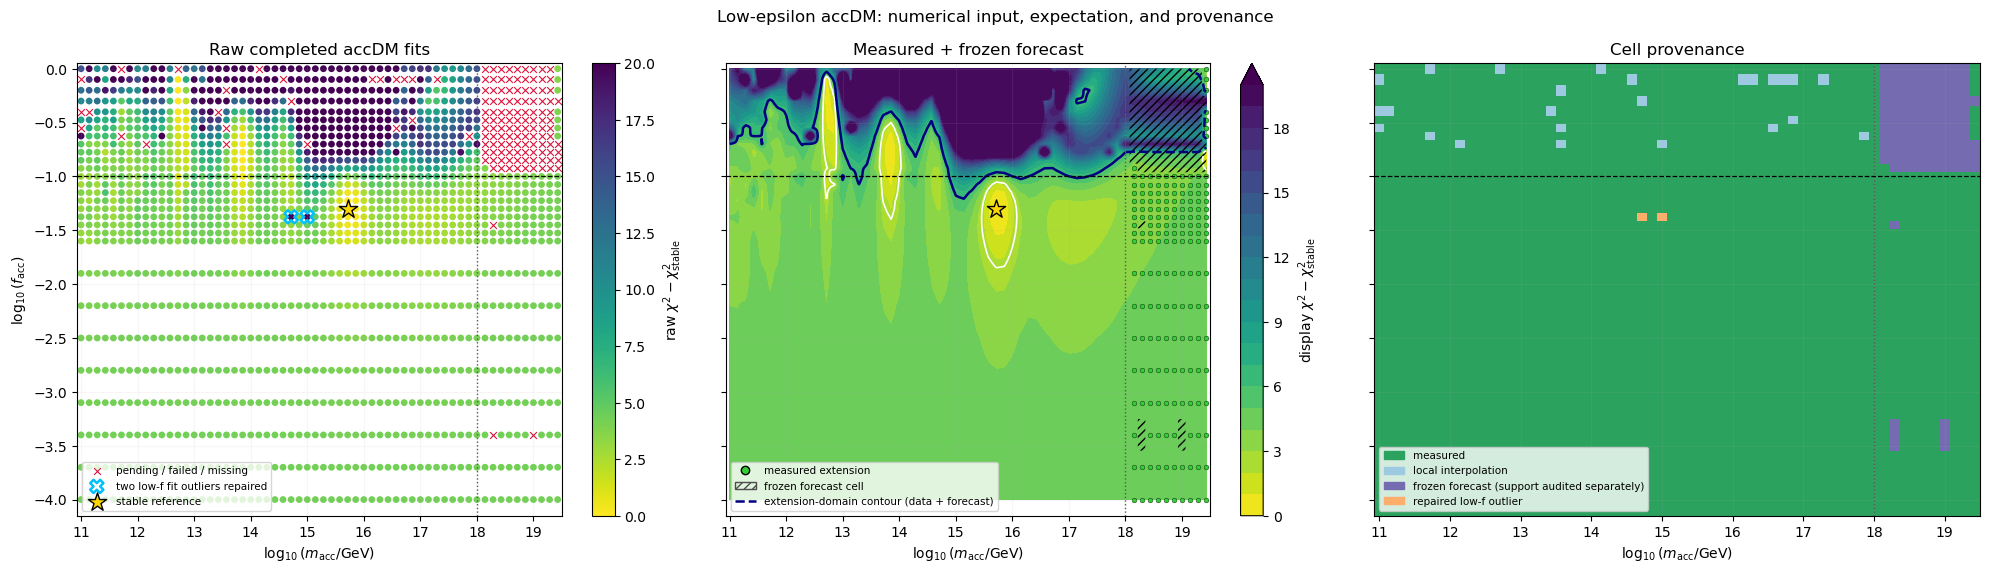

In [9]:
def dense_surface(values, nx=760, ny=600, method="linear"):
    x_dense = np.linspace(x_grid.min(), x_grid.max(), nx)
    y_dense = np.linspace(y_grid.min(), y_grid.max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)
    interpolator = RegularGridInterpolator(
        (y_grid, x_grid), values, method=method, bounds_error=False, fill_value=np.nan
    )
    dense = interpolator(np.column_stack([yy.ravel(), xx.ravel()])).reshape(xx.shape)
    return x_dense, y_dense, xx, yy, dense


x_dense, y_dense, xx_dense, yy_dense, delta_dense_raw = dense_surface(delta_surface_grid_raw)
_, _, _, _, provenance_forecast_dense = dense_surface(
    snapshot_forecast_grid.astype(float), method="nearest"
)


def smootherstep01(value):
    value = np.clip(np.asarray(value, dtype=float), 0.0, 1.0)
    return value**3 * (value * (value * 6.0 - 15.0) + 10.0)


# A second, explicitly illustrative surface answers a different question than
# the conservative snapshot: what would the unfinished low-epsilon region look
# like if it continuously approached the measured DCDM morphology?  Completed
# extension fits are overplotted later, but they do not deform this hypothesis.
dcdm_like_delta_dense = delta_dense_raw.copy()
dcdm_conditioned_dense = np.zeros_like(delta_dense_raw, dtype=bool)
extension_boundary_logeps = float(
    np.log10(epsilon_effective_from_log10_mass(ORIGINAL_MAX_LOGM))
)
dcdm_morphology_metrics = {
    "transition_width_log10epsilon": DCDM_MORPH_TRANSITION_DEX,
    "extension_boundary_log10epsilon": extension_boundary_logeps,
    "conditioned_dense_cells": 0,
    "deep_template_spearman": np.nan,
    "deep_template_max_abs_difference": np.nan,
    "boundary_max_abs_mismatch": np.nan,
}

if DCDM_AVAILABLE:
    dcdm_native_dense = evaluate_dcdm(xx_dense, yy_dense)
    logeps_native_dense = np.log10(epsilon_effective_from_log10_mass(xx_dense))
    dcdm_boundary_by_fraction = evaluate_dcdm(
        np.full_like(y_dense, ORIGINAL_MAX_LOGM), y_dense
    )
    accdm_boundary_by_fraction = np.asarray([
        np.interp(ORIGINAL_MAX_LOGM, x_dense, row) for row in delta_dense_raw
    ])
    depth = np.maximum(extension_boundary_logeps - logeps_native_dense, 0.0)
    morph_weight = smootherstep01(depth / DCDM_MORPH_TRANSITION_DEX)
    finite_boundary = (
        np.isfinite(dcdm_boundary_by_fraction)
        & np.isfinite(accdm_boundary_by_fraction)
    )
    dcdm_conditioned_dense = (
        (xx_dense > ORIGINAL_MAX_LOGM + 1e-12)
        & np.isfinite(dcdm_native_dense)
        & finite_boundary[:, None]
    )
    boundary_offset = (
        accdm_boundary_by_fraction - dcdm_boundary_by_fraction
    )[:, None]
    transferred = dcdm_native_dense + (1.0 - morph_weight) * boundary_offset
    dcdm_like_delta_dense[dcdm_conditioned_dense] = transferred[
        dcdm_conditioned_dense
    ]

    deep_template = (
        dcdm_conditioned_dense
        & (depth >= DCDM_MORPH_TRANSITION_DEX - 1e-12)
    )
    if np.count_nonzero(deep_template) >= 3:
        dcdm_morphology_metrics["deep_template_spearman"] = float(
            spearmanr(
                dcdm_like_delta_dense[deep_template],
                dcdm_native_dense[deep_template],
            )[0]
        )
        dcdm_morphology_metrics["deep_template_max_abs_difference"] = float(
            np.max(np.abs(
                dcdm_like_delta_dense[deep_template]
                - dcdm_native_dense[deep_template]
            ))
        )
    boundary_supported = finite_boundary
    if np.any(boundary_supported):
        reconstructed_boundary = (
            dcdm_boundary_by_fraction[boundary_supported]
            + accdm_boundary_by_fraction[boundary_supported]
            - dcdm_boundary_by_fraction[boundary_supported]
        )
        dcdm_morphology_metrics["boundary_max_abs_mismatch"] = float(
            np.max(np.abs(
                reconstructed_boundary
                - accdm_boundary_by_fraction[boundary_supported]
            ))
        )
    dcdm_morphology_metrics["conditioned_dense_cells"] = int(
        np.count_nonzero(dcdm_conditioned_dense)
    )

print("Illustrative DCDM-morphology forecast:")
display(pd.Series(dcdm_morphology_metrics, name="value").to_frame())

sampled_plot = sampled.copy()
sampled_plot["delta"] = sampled_plot["chi2_one_loop"] - REFERENCE_CHI2

fig_overview, axes = plt.subplots(1, 3, figsize=(20.0, 5.8), sharex=True, sharey=True)

raw_scatter = axes[0].scatter(
    sampled_plot["log10m_acc"], sampled_plot["log10f_acc"],
    c=np.clip(sampled_plot["delta"], 0, DISPLAY_DELTA_MAX),
    cmap="viridis_r", vmin=0, vmax=DISPLAY_DELTA_MAX,
    s=24, edgecolor="none", rasterized=True,
)
axes[0].scatter(
    missing_now["log10m_acc"], missing_now["log10f_acc"], marker="x", s=24,
    color="crimson", linewidth=0.8, label="pending / failed / missing",
)
if len(repair_audit):
    axes[0].scatter(
        repair_audit["log10m_acc"], repair_audit["log10f_acc"], marker="X", s=90,
        facecolor="none", edgecolor="deepskyblue", linewidth=1.8,
        label="two low-f fit outliers repaired",
    )
axes[0].scatter(
    [stable_reference["log10m_acc"]], [stable_reference["log10f_acc"]],
    marker="*", s=190, color="gold", edgecolor="black", label="stable reference",
)
axes[0].set_title("Raw completed accDM fits")
axes[0].legend(fontsize=7.5, loc="lower left")
fig_overview.colorbar(raw_scatter, ax=axes[0], label=r"raw $\chi^2-\chi^2_{\rm stable}$")

surface_plot = axes[1].contourf(
    x_dense, y_dense, np.clip(delta_dense_raw, 0, DISPLAY_DELTA_MAX),
    levels=np.linspace(0, DISPLAY_DELTA_MAX, 21), cmap="viridis_r", extend="max",
)
old_masked = np.ma.masked_where(xx_dense > ORIGINAL_MAX_LOGM + 1e-12, delta_dense_raw)
new_masked = np.ma.masked_where(xx_dense <= ORIGINAL_MAX_LOGM + 1e-12, delta_dense_raw)
axes[1].contour(
    x_dense, y_dense, old_masked,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D], colors=["white", "navy"],
    linewidths=[1.2, 1.8], linestyles="solid",
)
axes[1].contour(
    x_dense, y_dense, new_masked,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D], colors=["white", "navy"],
    linewidths=[1.2, 1.8], linestyles="dashed",
)
forecast_region = np.ma.masked_where(provenance_forecast_dense < 0.5, provenance_forecast_dense)
axes[1].contourf(
    x_dense, y_dense, forecast_region, levels=[0.5, 1.5],
    colors="none", hatches=["////"], alpha=0.0,
)
completed_extension = extension_completed.copy()
axes[1].scatter(
    completed_extension["log10m_acc"], completed_extension["log10f_acc"],
    s=12, color="limegreen", edgecolor="black", linewidth=0.25,
    label="measured extension",
)
axes[1].scatter(
    [stable_reference["log10m_acc"]], [stable_reference["log10f_acc"]],
    marker="*", s=190, color="gold", edgecolor="black",
)
axes[1].set_title("Measured + frozen forecast")
axes[1].legend(handles=[
    Line2D([], [], marker="o", color="none", markerfacecolor="limegreen",
           markeredgecolor="black", markersize=6, label="measured extension"),
    Patch(facecolor="none", edgecolor="0.3", hatch="////", label="frozen forecast cell"),
    Line2D([], [], color="navy", lw=1.8, ls="--",
           label="extension-domain contour (data + forecast)"),
], fontsize=7.5, loc="lower left")
fig_overview.colorbar(surface_plot, ax=axes[1], label=r"display $\chi^2-\chi^2_{\rm stable}$")

provenance_codes = np.zeros_like(chi_raw_grid, dtype=float)
provenance_codes[provenance_grid == "local_interpolation"] = 1
provenance_codes[snapshot_forecast_grid] = 2
provenance_codes[provenance_grid == "repaired_lowf_outlier"] = 3
provenance_cmap = ListedColormap(["#2ca25f", "#9ecae1", "#756bb1", "#fdae6b"])
provenance_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], provenance_cmap.N)
axes[2].pcolormesh(x_grid, y_grid, provenance_codes, shading="nearest",
                   cmap=provenance_cmap, norm=provenance_norm)
axes[2].set_title("Cell provenance")
axes[2].legend(handles=[
    Patch(color="#2ca25f", label="measured"),
    Patch(color="#9ecae1", label="local interpolation"),
    Patch(color="#756bb1", label="frozen forecast (support audited separately)"),
    Patch(color="#fdae6b", label="repaired low-f outlier"),
], fontsize=7.5, loc="lower left")

for axis in axes:
    axis.axvline(ORIGINAL_MAX_LOGM, color="0.35", ls=":", lw=1.0)
    axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=0.9)
    axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
    axis.grid(alpha=0.10)
axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
fig_overview.suptitle("Low-epsilon accDM: numerical input, expectation, and provenance")
fig_overview.tight_layout()
plt.show()


## 9. Mapa oczekiwana już teraz — bez czekania na nowe fity

To jest właściwy **ilustracyjny** rysunek oczekiwanej morfologii. Powstaje przy
bieżącym uruchomieniu bez czekania na następne fity. Na granicy starej siatki
$\log_{10}m_{\rm acc}=18$ jest zakotwiczony do accDM, a w nowym zakresie płynnie
przechodzi do pełnego kształtu DCDM. Dzięki temu nie przenosi w dół sztucznej,
zależnej od frakcji ściany z lokalnej ekstrapolacji accDM.

Ukończone punkty rozszerzenia są nakładane jako zielone markery kontrolne, lecz
nie deformują pola koloru. Kreskowanie oznacza obszar, w którym narzucono hipotezę
morfologii DCDM; dwa pomarańczowe kwadraty to interpolowane low-f outliery.

Pliki `expected_loweps_map_now.png` i `expected_loweps_map_now.pdf` są zapisywane
od razu w `OUTPUT_DIR`. Nie zależą od późniejszej sekcji „prediction vs reality”.


Saved immediate expected map:
  /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1/expected_loweps_map_now.png
  /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1/expected_loweps_map_now.pdf


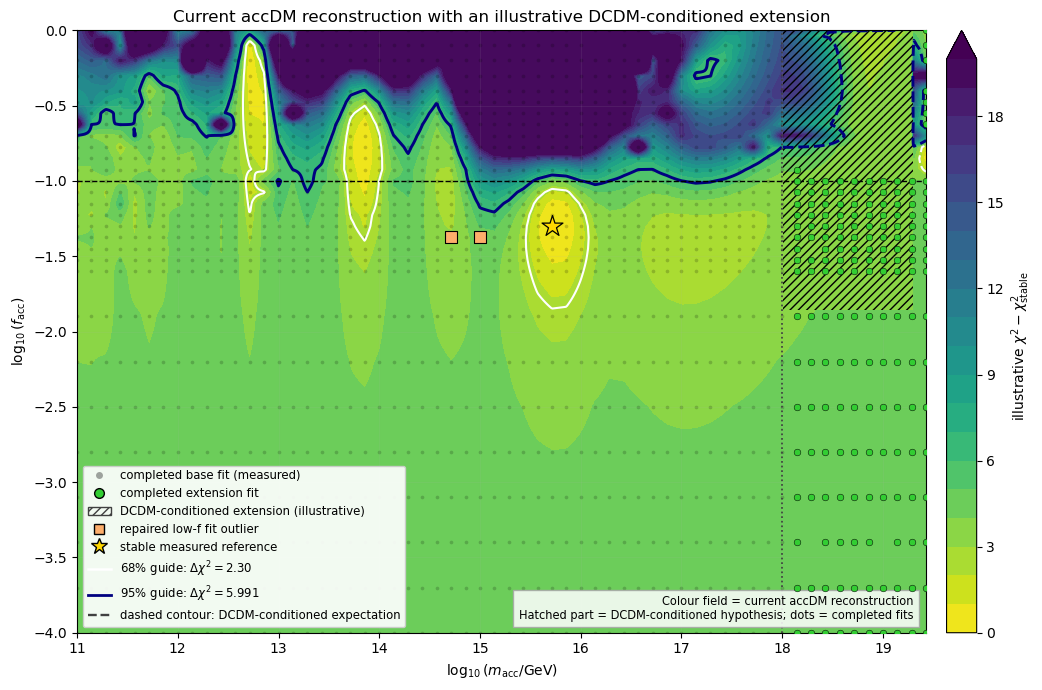

In [10]:
fig_expected_now, ax = plt.subplots(figsize=(11.2, 7.0))

expected_fill = ax.contourf(
    x_dense,
    y_dense,
    np.clip(dcdm_like_delta_dense, 0.0, DISPLAY_DELTA_MAX),
    levels=np.linspace(0.0, DISPLAY_DELTA_MAX, 21),
    cmap="viridis_r",
    extend="max",
)

# Solid contours in the original measured domain; dashed contours in the new
# low-epsilon extension, where measurements and forecast can coexist.
old_expected = np.ma.masked_where(
    xx_dense > ORIGINAL_MAX_LOGM + 1e-12, dcdm_like_delta_dense
)
new_expected = np.ma.masked_where(
    xx_dense <= ORIGINAL_MAX_LOGM + 1e-12, dcdm_like_delta_dense
)
ax.contour(
    x_dense,
    y_dense,
    old_expected,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"],
    linewidths=[1.5, 2.1],
    linestyles="solid",
)
ax.contour(
    x_dense,
    y_dense,
    new_expected,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"],
    linewidths=[1.5, 2.1],
    linestyles="dashed",
)

forecast_cells_dense = np.ma.masked_where(
    ~dcdm_conditioned_dense, dcdm_conditioned_dense.astype(float)
)
ax.contourf(
    x_dense,
    y_dense,
    forecast_cells_dense,
    levels=[0.5, 1.5],
    colors="none",
    hatches=["////"],
    alpha=0.0,
)

# Numerical support is shown only as markers.  In the extension those markers
# test the DCDM-conditioned hypothesis but do not warp its colour field.
ax.scatter(
    sampled_plot.loc[sampled_plot["log10m_acc"] <= ORIGINAL_MAX_LOGM, "log10m_acc"],
    sampled_plot.loc[sampled_plot["log10m_acc"] <= ORIGINAL_MAX_LOGM, "log10f_acc"],
    s=7,
    color="black",
    alpha=0.18,
    linewidth=0,
)
if len(completed_extension):
    ax.scatter(
        completed_extension["log10m_acc"],
        completed_extension["log10f_acc"],
        s=23,
        facecolor="limegreen",
        edgecolor="black",
        linewidth=0.35,
        zorder=5,
    )
if len(repair_audit):
    ax.scatter(
        repair_audit["log10m_acc"],
        repair_audit["log10f_acc"],
        marker="s",
        s=82,
        facecolor="#fdae6b",
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
    )
ax.scatter(
    [stable_reference["log10m_acc"]],
    [stable_reference["log10f_acc"]],
    marker="*",
    s=250,
    facecolor="gold",
    edgecolor="black",
    linewidth=0.9,
    zorder=7,
)

ax.axvspan(
    ORIGINAL_MAX_LOGM,
    x_grid.max(),
    color="white",
    alpha=0.035,
    zorder=0,
)
ax.axvline(ORIGINAL_MAX_LOGM, color="0.25", ls=":", lw=1.25)
ax.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1.0)
ax.set_xlim(x_grid.min(), x_grid.max())
ax.set_ylim(y_grid.min(), y_grid.max())
ax.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
ax.set_ylabel(r"$\log_{10}(f_{\rm acc})$")
ax.set_title("Current accDM reconstruction with an illustrative DCDM-conditioned extension")
ax.grid(alpha=0.10)
ax.text(
    0.985,
    0.018,
    "Colour field = current accDM reconstruction\n"
    "Hatched part = DCDM-conditioned hypothesis; dots = completed fits",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.2,
    bbox={"facecolor": "white", "edgecolor": "0.65", "alpha": 0.86, "pad": 4},
)

ax.legend(
    handles=[
        Line2D(
            [], [], marker="o", color="none", markerfacecolor="black",
            markeredgecolor="none", alpha=0.35, markersize=5,
            label="completed base fit (measured)",
        ),
        Line2D(
            [], [], marker="o", color="none", markerfacecolor="limegreen",
            markeredgecolor="black", markersize=7, label="completed extension fit",
        ),
        Patch(
            facecolor="none", edgecolor="0.25", hatch="////",
            label="DCDM-conditioned extension (illustrative)",
        ),
        Line2D(
            [], [], marker="s", color="none", markerfacecolor="#fdae6b",
            markeredgecolor="black", markersize=7, label="repaired low-f fit outlier",
        ),
        Line2D(
            [], [], marker="*", color="none", markerfacecolor="gold",
            markeredgecolor="black", markersize=12, label="stable measured reference",
        ),
        Line2D([], [], color="white", lw=1.8, label=r"68% guide: $\Delta\chi^2=2.30$"),
        Line2D([], [], color="navy", lw=2.0, label=r"95% guide: $\Delta\chi^2=5.991$"),
        Line2D(
            [], [], color="0.25", lw=1.7, ls="--",
            label="dashed contour: DCDM-conditioned expectation",
        ),
    ],
    loc="lower left",
    fontsize=8.4,
    framealpha=0.92,
)

fig_expected_now.colorbar(
    expected_fill,
    ax=ax,
    label=r"illustrative $\chi^2-\chi^2_{\rm stable}$",
    pad=0.02,
)
fig_expected_now.tight_layout()

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_expected_now.savefig(
        OUTPUT_DIR / "expected_loweps_map_now.png", dpi=260, bbox_inches="tight"
    )
    fig_expected_now.savefig(
        OUTPUT_DIR / "expected_loweps_map_now.pdf", bbox_inches="tight"
    )
    fig_expected_now.savefig(
        OUTPUT_DIR / "dcdm_like_expected_map_now.png", dpi=260, bbox_inches="tight"
    )
    fig_expected_now.savefig(
        OUTPUT_DIR / "dcdm_like_expected_map_now.pdf", bbox_inches="tight"
    )
    print("Saved immediate expected map:")
    print(" ", OUTPUT_DIR / "expected_loweps_map_now.png")
    print(" ", OUTPUT_DIR / "expected_loweps_map_now.pdf")

plt.show()


## 10. Bezpośrednie porównanie na osiach DCDM

Ten rysunek celowo pokazuje wyłącznie wspólny zakres DCDM i accDM oraz robi zoom
na nową domenę $\log_{10}\epsilon<-3.34968$. Po lewej jest wejściowy szablon DCDM,
a po prawej ilustracyjna hipoteza accDM: dokładnie zakotwiczona na starej granicy
i płynnie przechodząca do pełnej morfologii DCDM. Zielone punkty są ukończonymi
fitami kontrolnymi i nie zmieniają pola koloru. Zakres $\log_{10}\Gamma$ bez danych
DCDM jest wycięty, ponieważ nie można tam uczciwie oceniać podobieństwa.


Saved direct low-epsilon morphology comparison:
  /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1/dcdm_like_loweps_comparison_now.png
  /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1/dcdm_like_loweps_comparison_now.pdf


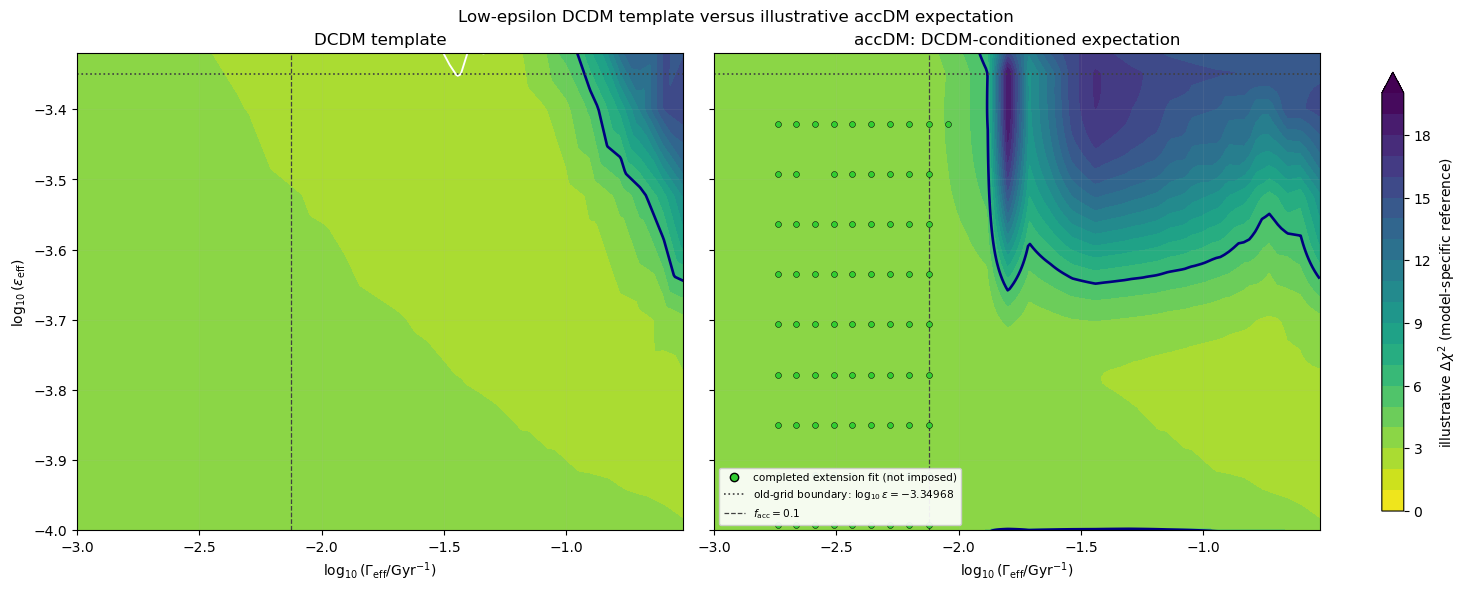

In [11]:
fig_common_coordinates = None
if DCDM_AVAILABLE:
    dgamma_dense = np.linspace(dcdm_gamma_axis.min(), dcdm_gamma_axis.max(), 600)
    depsilon_dense = np.linspace(dcdm_epsilon_axis.min(), dcdm_epsilon_axis.max(), 520)
    dg_mesh, de_mesh = np.meshgrid(dgamma_dense, depsilon_dense)
    dcdm_dense = dcdm_interpolator(
        np.column_stack([de_mesh.ravel(), dg_mesh.ravel()])
    ).reshape(de_mesh.shape)

    gamma_dense_native = gamma_effective_from_log10_fraction(y_dense)
    valid_gamma_rows = np.isfinite(gamma_dense_native) & (gamma_dense_native > 0)
    loggamma_accdm = np.log10(gamma_dense_native[valid_gamma_rows])
    logepsilon_accdm = np.log10(epsilon_effective_from_log10_mass(x_dense[::-1]))
    dcdm_like_effective = dcdm_like_delta_dense[valid_gamma_rows, ::-1].T

    common_gamma_min = float(max(dcdm_gamma_axis.min(), loggamma_accdm.min()))
    common_gamma_max = float(min(dcdm_gamma_axis.max(), loggamma_accdm.max()))
    common_epsilon_min = float(max(dcdm_epsilon_axis.min(), logepsilon_accdm.min()))
    common_epsilon_max = float(min(
        extension_boundary_logeps + 0.03,
        dcdm_epsilon_axis.max(),
        logepsilon_accdm.max(),
    ))
    transition_gamma = float(np.log10(
        gamma_effective_from_log10_fraction(TRANSITION_LOGF)
    ))

    fig_common_coordinates, axes = plt.subplots(
        1, 2, figsize=(14.6, 5.8), sharex=True, sharey=True,
        constrained_layout=True,
    )
    common_levels = np.linspace(0, DISPLAY_DELTA_MAX, 21)
    axes[0].contourf(
        dgamma_dense, depsilon_dense, np.clip(dcdm_dense, 0, DISPLAY_DELTA_MAX),
        levels=common_levels, cmap="viridis_r", extend="max",
    )
    axes[0].contour(
        dgamma_dense, depsilon_dense, dcdm_dense,
        levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
        colors=["white", "navy"], linewidths=[1.35, 1.9],
    )
    axes[0].set_title("DCDM template")

    plotted = axes[1].contourf(
        loggamma_accdm, logepsilon_accdm,
        np.clip(dcdm_like_effective, 0, DISPLAY_DELTA_MAX),
        levels=common_levels, cmap="viridis_r", extend="max",
    )
    axes[1].contour(
        loggamma_accdm, logepsilon_accdm, dcdm_like_effective,
        levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
        colors=["white", "navy"], linewidths=[1.35, 1.9],
    )
    if len(completed_extension):
        point_gamma = gamma_effective_from_log10_fraction(
            completed_extension["log10f_acc"]
        )
        point_epsilon = np.log10(epsilon_effective_from_log10_mass(
            completed_extension["log10m_acc"]
        ))
        finite = (
            np.isfinite(point_gamma) & (point_gamma > 0)
            & np.isfinite(point_epsilon)
        )
        axes[1].scatter(
            np.log10(point_gamma[finite]), point_epsilon[finite],
            s=18, facecolor="limegreen", edgecolor="black",
            linewidth=0.35, zorder=5,
        )
    axes[1].set_title("accDM: DCDM-conditioned expectation")

    for axis in axes:
        axis.axhline(extension_boundary_logeps, color="0.25", ls=":", lw=1.2)
        axis.axvline(transition_gamma, color="0.25", ls="--", lw=0.9)
        axis.set_xlim(common_gamma_min, common_gamma_max)
        axis.set_ylim(common_epsilon_min, common_epsilon_max)
        axis.set_xlabel(r"$\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})$")
        axis.grid(alpha=0.10)
    axes[0].set_ylabel(r"$\log_{10}(\epsilon_{\rm eff})$")
    axes[1].legend(handles=[
        Line2D([], [], marker="o", color="none",
               markerfacecolor="limegreen", markeredgecolor="black",
               markersize=6, label="completed extension fit (not imposed)"),
        Line2D([], [], color="0.25", ls=":", lw=1.2,
               label=r"old-grid boundary: $\log_{10}\epsilon=-3.34968$"),
        Line2D([], [], color="0.25", ls="--", lw=0.9,
               label=r"$f_{\rm acc}=0.1$"),
    ], loc="lower left", fontsize=7.6, framealpha=0.92)
    fig_common_coordinates.colorbar(
        plotted, ax=axes,
        label=r"illustrative $\Delta\chi^2$ (model-specific reference)",
        shrink=0.92,
    )
    fig_common_coordinates.suptitle(
        "Low-epsilon DCDM template versus illustrative accDM expectation"
    )

    if SAVE_OUTPUTS:
        fig_common_coordinates.savefig(
            OUTPUT_DIR / "dcdm_like_loweps_comparison_now.png",
            dpi=260, bbox_inches="tight",
        )
        fig_common_coordinates.savefig(
            OUTPUT_DIR / "dcdm_like_loweps_comparison_now.pdf",
            bbox_inches="tight",
        )
        print("Saved direct low-epsilon morphology comparison:")
        print(" ", OUTPUT_DIR / "dcdm_like_loweps_comparison_now.png")
        print(" ", OUTPUT_DIR / "dcdm_like_loweps_comparison_now.pdf")
    plt.show()
else:
    print("Common-coordinate DCDM comparison skipped in local-only mode.")


## 11. Siła podparcia prognozy i rozbieżność metod

Waga DCDM mówi, jak duża część prognozy pochodzi z szablonu DCDM. Drugi panel pokazuje
$|\chi^2_{\rm DCDM-guided}-\chi^2_{\rm local}|$; duża wartość oznacza, że oczekiwanie
jest silnie zależne od przyjętego modelu interpolacji i zasługuje na szczególną uwagę
po zakończeniu runów.


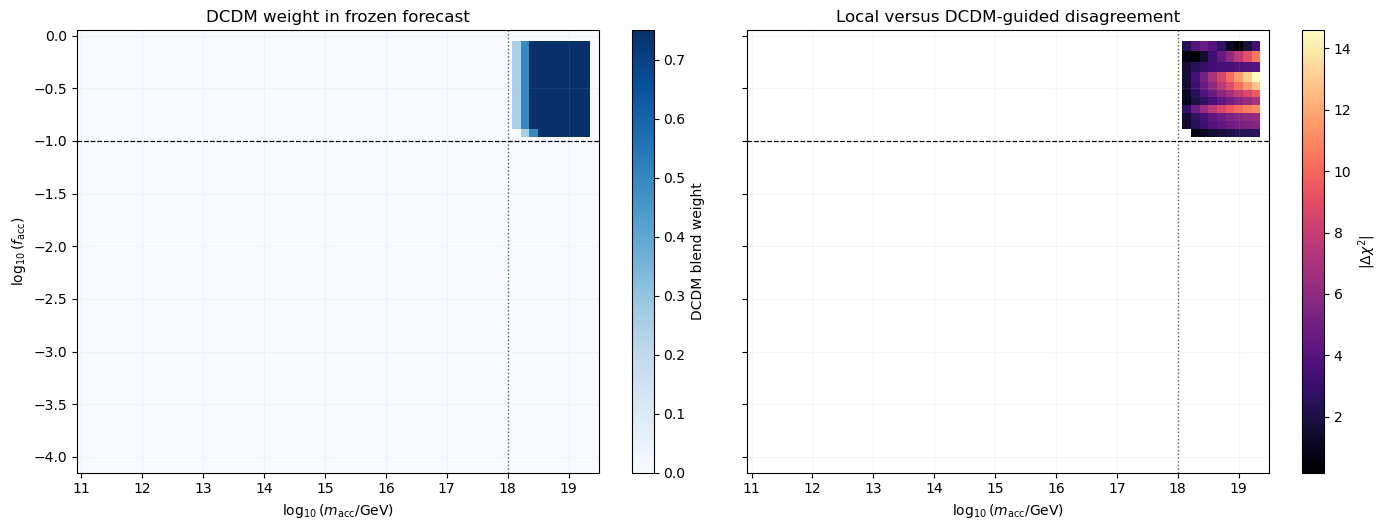

In [12]:
fig_support, axes = plt.subplots(1, 2, figsize=(14.2, 5.4), sharex=True, sharey=True)
weight_plot = axes[0].pcolormesh(
    x_grid, y_grid, dcdm_weight_grid, shading="nearest", cmap="Blues",
    vmin=0, vmax=max(0.75, DCDM_MAX_WEIGHT),
)
axes[0].set_title("DCDM weight in frozen forecast")
fig_support.colorbar(weight_plot, ax=axes[0], label="DCDM blend weight")

disagreement_plot = axes[1].pcolormesh(
    x_grid, y_grid, np.ma.masked_invalid(disagreement_grid),
    shading="nearest", cmap="magma",
)
axes[1].set_title("Local versus DCDM-guided disagreement")
fig_support.colorbar(disagreement_plot, ax=axes[1], label=r"$|\Delta\chi^2|$")

for axis in axes:
    axis.axvline(ORIGINAL_MAX_LOGM, color="0.35", ls=":", lw=1.0)
    axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=0.9)
    axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
    axis.grid(alpha=0.10)
axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
fig_support.tight_layout()
plt.show()


## 12. Automatyczna walidacja konserwatywnego snapshotu po nowych fitach

Porównywane są wyłącznie punkty, które były brakujące przy tworzeniu snapshotu.
Punkty użyte do kalibracji nie są liczone jako sukces prognozy. Ponowne wykonanie
notebooka po zakończeniu jobów zaktualizuje tę komórkę bez zmiany snapshotu. Ta
sekcja dotyczy konserwatywnej prognozy audytowej, a nie ilustracyjnej powierzchni
DCDM-conditioned z sekcji 9–10.


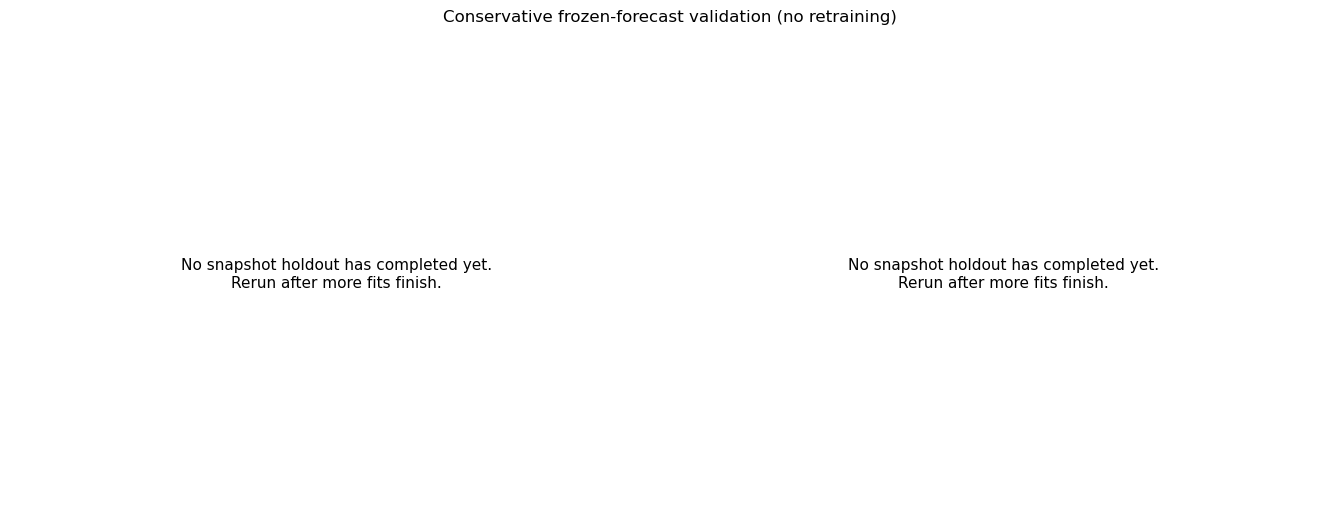

,value
validated_points,0.0
mean_error,NaN
median_error,NaN
mae,NaN
rmse,NaN
spearman,NaN
changed_95pct_classifications,0.0


In [13]:
current_actual = sampled[[
    "coordinate_key", "chi2_one_loop", "source_label"
]].rename(columns={"chi2_one_loop": "actual_chi2"})
validation = prediction_snapshot.merge(
    current_actual, on="coordinate_key", how="inner", validate="one_to_one"
)
validation["residual_actual_minus_prediction"] = (
    validation["actual_chi2"] - validation["predicted_chi2"]
)
validation["absolute_error"] = validation["residual_actual_minus_prediction"].abs()
validation["predicted_inside_95pct"] = (
    validation["predicted_chi2"] - REFERENCE_CHI2 <= DELTA_CHI2_95_2D
)
validation["actual_inside_95pct"] = (
    validation["actual_chi2"] - REFERENCE_CHI2 <= DELTA_CHI2_95_2D
)
validation["classification_changed_95pct"] = (
    validation["predicted_inside_95pct"] != validation["actual_inside_95pct"]
)

fig_validation, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
if len(validation):
    color = validation["log10f_acc"]
    scatter = axes[0].scatter(
        validation["predicted_chi2"], validation["actual_chi2"],
        c=color, cmap="plasma", s=38, edgecolor="black", linewidth=0.25,
    )
    limits = [
        min(validation["predicted_chi2"].min(), validation["actual_chi2"].min()),
        max(validation["predicted_chi2"].max(), validation["actual_chi2"].max()),
    ]
    axes[0].plot(limits, limits, "k--", lw=1.0)
    axes[0].set_xlabel(r"frozen predicted $\chi^2$")
    axes[0].set_ylabel(r"actual completed $\chi^2$")
    axes[0].set_title("Prediction versus reality")
    fig_validation.colorbar(scatter, ax=axes[0], label=r"$\log_{10}(f_{\rm acc})$")

    residual_scatter = axes[1].scatter(
        validation["log10m_acc"], validation["log10f_acc"],
        c=validation["residual_actual_minus_prediction"], cmap="coolwarm",
        s=52, edgecolor="black", linewidth=0.25,
    )
    axes[1].axvline(ORIGINAL_MAX_LOGM, color="0.35", ls=":", lw=1.0)
    axes[1].axhline(TRANSITION_LOGF, color="black", ls="--", lw=0.9)
    axes[1].set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
    axes[1].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
    axes[1].set_title("Actual minus frozen prediction")
    fig_validation.colorbar(residual_scatter, ax=axes[1], label=r"$\Delta\chi^2$")
    validation_metrics = {
        "validated_points": int(len(validation)),
        "mean_error": float(validation["residual_actual_minus_prediction"].mean()),
        "median_error": float(validation["residual_actual_minus_prediction"].median()),
        "mae": float(validation["absolute_error"].mean()),
        "rmse": float(np.sqrt(np.mean(validation["residual_actual_minus_prediction"] ** 2))),
        "spearman": float(spearmanr(validation["predicted_chi2"], validation["actual_chi2"])[0])
            if len(validation) >= 3 else np.nan,
        "changed_95pct_classifications": int(validation["classification_changed_95pct"].sum()),
    }
else:
    validation_metrics = {
        "validated_points": 0, "mean_error": np.nan, "median_error": np.nan,
        "mae": np.nan, "rmse": np.nan, "spearman": np.nan,
        "changed_95pct_classifications": 0,
    }
    for axis in axes:
        axis.text(
            0.5, 0.5, "No snapshot holdout has completed yet.\nRerun after more fits finish.",
            transform=axis.transAxes, ha="center", va="center", fontsize=11,
        )
        axis.set_axis_off()
fig_validation.suptitle("Conservative frozen-forecast validation (no retraining)")
fig_validation.tight_layout()
plt.show()

display(pd.Series(validation_metrics, name="value").to_frame())


## 13. Eksport audytowalnych produktów

- `loweps_prediction_snapshot.csv` — niezmienna prognoza punktów brakujących w chwili
  utworzenia snapshotu;
- `loweps_prediction_surface_current.csv` — aktualna mapa z rozróżnieniem pochodzenia;
- `loweps_prediction_validation.csv` — późniejsze wyniki kontra snapshot;
- `repaired_lowf_outliers.csv` — surowe i interpolowane wartości dwóch dziur;
- `expected_loweps_map_now.png/.pdf` oraz `dcdm_like_expected_map_now.png/.pdf`
  — ilustracyjna mapa oczekiwania zakotwiczona do accDM i przechodząca w DCDM;
- `dcdm_like_loweps_comparison_now.png/.pdf` — bezpośredni zoom nowej domeny na
  wspólnym zakresie obu modeli;
- pozostałe PNG — rysunki kontrolne i późniejsza walidacja;
- JSON — ustawienia, pokrycie i metryki.


In [14]:
metadata = {
    "purpose": "diagnostic DCDM-guided forecast; not final statistical inference",
    "snapshot_mode": SNAPSHOT_MODE,
    "snapshot_signature": SNAPSHOT_SIGNATURE,
    "project_root": str(PROJECT_ROOT),
    "base_analysis_directory": str(BASE_ANALYSIS_DIR),
    "dcdm_profile_csv": str(DCDM_PROFILE_CSV) if DCDM_PROFILE_CSV else None,
    "dcdm_file_hash": DCDM_FILE_HASH,
    "dcdm_available": bool(DCDM_AVAILABLE),
    "stable_reference": {
        "coordinate_key": str(stable_reference["coordinate_key"]),
        "point_id": str(stable_reference.get("point_id", "n/a")),
        "log10m_acc": float(stable_reference["log10m_acc"]),
        "log10f_acc": float(stable_reference["log10f_acc"]),
        "log10_epsilon_eff": float(stable_reference["log10_epsilon_eff"]),
        "chi2": REFERENCE_CHI2,
    },
    "extension_status": {
        str(label): {key: float(value) if key == "coverage" else int(value)
                     for key, value in row.items()}
        for label, row in extension_status.to_dict(orient="index").items()
    },
    "completed_extension_fits_now": int(len(extension_completed)),
    "missing_grid_cells_now": int(len(missing_now)),
    "repaired_lowf_outliers": int(len(repair_audit)),
    "frozen_calibration": FROZEN_CALIBRATION,
    "live_recalculation_not_used_to_change_frozen_snapshot": {
        "pairs": int(len(d_template)),
        "beta": DCDM_BETA,
        "spearman": CALIBRATION_SPEARMAN,
        "max_weight": DCDM_MAX_WEIGHT,
        "weight_selection_method": WEIGHT_SELECTION_METHOD,
    },
    "fit_trust_audit": {
        "completed_points": int(len(sampled)),
        "trusted_forecast_anchors": int(sampled["trusted_for_forecast"].sum()),
        "require_optimizer_success": bool(TRUST_REQUIRE_OPTIMIZER_SUCCESS),
        "minimum_bound_distance_when_available": MIN_TRUSTED_BOUND_DISTANCE,
    },
    "frozen_holdout_points": int(len(prediction_snapshot)),
    "validation": validation_metrics,
    "illustrative_dcdm_morphology": dcdm_morphology_metrics,
    "warnings": [
        "forecast_cells_are_not_measured_likelihood_values",
        "dcdm_shape_is_a_heuristic_prior_not_an_exact_model_mapping",
        "low_and_high_fraction_regions_are_never_interpolated_across_q_boundary",
        "negative_delta_chi2_is_clipped_only_for_display",
        "dcdm_like_surface_is_an_illustrative_template_conditioned_hypothesis",
        "completed_extension_markers_do_not_deform_the_dcdm_like_colour_field",
    ],
}

if SAVE_OUTPUTS:
    current_surface.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
        OUTPUT_DIR / "loweps_prediction_surface_current.csv", index=False
    )
    validation.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
        OUTPUT_DIR / "loweps_prediction_validation.csv", index=False
    )
    repair_audit.to_csv(OUTPUT_DIR / "repaired_lowf_outliers.csv", index=False)
    cv_summary.to_csv(OUTPUT_DIR / "dcdm_weight_cross_validation.csv", index=False)
    cv_folds.to_csv(OUTPUT_DIR / "dcdm_cross_validation_folds.csv", index=False)
    (OUTPUT_DIR / "loweps_prediction_run_metadata.json").write_text(
        json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )
    fig_overview.savefig(
        OUTPUT_DIR / "measured_vs_expected_surface.png", dpi=220, bbox_inches="tight"
    )
    if fig_common_coordinates is not None:
        fig_common_coordinates.savefig(
            OUTPUT_DIR / "dcdm_accdm_common_coordinates.png", dpi=220, bbox_inches="tight"
        )
    fig_support.savefig(
        OUTPUT_DIR / "prediction_support_and_disagreement.png", dpi=220, bbox_inches="tight"
    )
    fig_validation.savefig(
        OUTPUT_DIR / "prediction_vs_reality.png", dpi=220, bbox_inches="tight"
    )
    print("Saved forecast products to:", OUTPUT_DIR)

display(pd.Series(metadata, name="value").to_frame())


Saved forecast products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_guided_loweps_forecast_v1


,value
purpose,diagnostic DCDM-guided forecast; not final sta...
snapshot_mode,loaded_frozen
snapshot_signature,7461919ba49c874bdd4c32210d4588f5e37ac68870a05f...
project_root,/home/2/ks405818/Master/lyalpha_one_loop
base_analysis_directory,/home/2/ks405818/Master/lyalpha_one_loop/runs/...
dcdm_profile_csv,/home/2/ks405818/Master/lyalpha_one_loop/runs/...
dcdm_file_hash,de6831eaa56e63c56ce0d9aee722110d007d085f8425a1...
dcdm_available,True
stable_reference,{'coordinate_key': '15.7142857143|-1.300000000...
extension_status,"{'loweps_high_q5001': {'planned': 120, 'theory..."
